# Lección 4.1 · Alineamiento múltiple de secuencias (MSA)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-04-msa-motivos-hmm/4.1_alineamiento_multiple.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 4 — Alineamiento múltiple, motivos y perfiles** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3.5 horas | Intermedio | Lecciones 3.2 (programación dinámica) y 3.3 (BLOSUM, huecos afines) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Explicar** por qué alinear muchas secuencias a la vez revela cosas que ningún alineamiento por pares muestra:
   la **conservación** sólo se ve mirando **columnas**.
2. **Demostrar** con números por qué la programación dinámica exacta con $k$ secuencias es impracticable
   ($O(n^k\,2^k)$) y **ejecutar** el caso exacto de tres secuencias.
3. **Calcular a mano** el puntaje **suma de pares** (SP) de una columna y de un alineamiento completo.
4. **Construir** un **árbol guía** con UPGMA a partir de una matriz de distancias y **dibujarlo**.
5. **Programar** un alineador **progresivo** (perfil contra perfil con programación dinámica) y **explicar** la regla
   "una vez hueco, siempre hueco".
6. **Comparar** su alineador con MAFFT y MUSCLE usando las métricas **SP** y **TC**, y **medir** el efecto de la
   penalización por hueco en datos simulados donde se conoce la verdad.
7. **Visualizar** un MSA real (citocromo *c* de 14 eucariotas) como mosaico coloreado por química, con perfil de
   conservación (entropía de Shannon) y secuencia consenso.

## 🗺️ Mapa de la clase

1. ¿Por qué alinear muchas secuencias a la vez?
2. Los datos: citocromo *c*, una proteína de 1 500 millones de años
3. La programación dinámica en $k$ dimensiones: exacta pero imposible
4. ¿Cómo se puntúa un MSA? La suma de pares (SP)
5. La estrategia progresiva de Feng y Doolittle
6. Paso 1: distancias por pares
7. Paso 2: el árbol guía con UPGMA (🎬 animación)
8. Paso 3: alinear perfiles contra perfiles
9. 🎬 El alineamiento progresivo en acción
10. 🧪 Nuestro MSA frente a MAFFT y MUSCLE
11. Leer un MSA: mosaico químico, conservación y consenso (visor interactivo)
12. 🧪 ¿Qué tan bueno es un MSA? SP, TC y el costo de los huecos en datos simulados
13. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import shutil, subprocess, time, math, itertools, io
import plotly.express as px
import plotly.graph_objects as go
from matplotlib.patches import Rectangle
from matplotlib.colors import to_rgb
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

try:
    import Bio
except ImportError:
    %pip install -q biopython
    import Bio
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Align import PairwiseAligner, substitution_matrices

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"
BLOSUM62 = substitution_matrices.load("BLOSUM62")
AA = "ARNDCQEGHILKMFPSTWYV"

# Clases químicas de los aminoácidos (inspiradas en el esquema ClustalX de Jalview) y su color fijo
AA_CLASS = {**{a: "hidrofóbico" for a in "AVLIM"}, **{a: "aromático" for a in "FWY"},
            **{a: "positivo" for a in "KRH"}, **{a: "negativo" for a in "DE"},
            **{a: "polar" for a in "STNQ"}, "G": "glicina", "P": "prolina", "C": "cisteína"}
CLASS_COLOR = {"hidrofóbico": ec.BLUE, "aromático": ec.VIOLET, "positivo": ec.RED, "negativo": ec.MAGENTA,
               "polar": ec.GREEN, "glicina": ec.YELLOW, "prolina": ec.ORANGE, "cisteína": ec.AQUA}
CLASSES = list(CLASS_COLOR)

def soft(color, alpha=0.45):
    """Mezcla un color con el fondo: los mosaicos usan tonos suaves para que la letra se lea."""
    r, g, b = to_rgb(color); s = to_rgb(ec.SURFACE)
    return tuple(alpha * c + (1 - alpha) * f for c, f in zip((r, g, b), s))

Entorno listo ✔  |  Colab: False


## 1. ¿Por qué alinear muchas secuencias a la vez?

En el Módulo 3 aprendimos a alinear **dos** secuencias. Con dos secuencias podemos decir "estas posiciones se
corresponden" y "aquí hubo una sustitución". Pero hay preguntas que un par no puede responder:

* ¿Esta posición está **conservada** en todos los organismos, o sólo coincidió por azar en estos dos?
* ¿Qué residuos son **indispensables** para la función (el sitio activo, el sitio de unión al hemo)?
* ¿Dónde tienden a aparecer **inserciones y deleciones** a lo largo de la evolución?

Piense en un examen que respondieron cien estudiantes. Si compara sólo dos exámenes y ve que ambos respondieron
"B" en la pregunta 7, no sabe si es la respuesta correcta o una coincidencia. Si pone los cien exámenes uno debajo
del otro y **mira la columna** de la pregunta 7, y los cien dicen "B", ya no tiene dudas. Un **alineamiento
múltiple de secuencias** (MSA, *multiple sequence alignment*) hace exactamente eso: coloca $k$ secuencias en filas,
con huecos, de modo que cada **columna** reúna posiciones **homólogas** (descendientes del mismo residuo ancestral).

```
            columna →  1 2 3 4 5 6 7 8
Humano                 G K K I F V Q K
Pollo                  G K K I F V Q K
Mosca                  G K K I F V Q K
Levadura               G A T L F K T R
Arabidopsis            G E K I F R T K
                       ↑       ↑
             G y F: idénticas en las cinco → probablemente importantes
```

El MSA es la **materia prima** de casi todo lo que viene en este módulo y en el siguiente:

| Uso del MSA | Dónde lo veremos |
|---|---|
| Perfiles de conservación y secuencias consenso | esta lección |
| Motivos y logos de secuencia (PWM) | Lección 4.2 |
| Perfiles HMM (Pfam, HMMER) | Lección 4.3 |
| Árboles filogenéticos | Módulo 5 |
| Predicción de estructura (AlphaFold usa MSA profundos) | más adelante en el curso |

Y lo más importante: **un error en el MSA se propaga** a todo lo que se construye encima. Por eso vale la pena
entender cómo se hace.

## 2. Los datos: citocromo *c*, una proteína de 1 500 millones de años

El **citocromo *c*** es una proteína pequeña (≈ 104–114 aminoácidos) que transporta electrones en la cadena
respiratoria de la mitocondria y que, además, dispara la apoptosis cuando sale al citoplasma. Está en todos los
eucariotas con mitocondria, así que existía ya en el ancestro común de animales, hongos y plantas. Es un ejemplo
clásico de la evolución molecular: sus secuencias se usaron en los años 60 para construir algunos de los primeros
árboles filogenéticos basados en proteínas.

Descargamos de **UniProt** (entradas revisadas, Swiss-Prot) el citocromo *c* de 14 especies: siete vertebrados, dos
invertebrados, dos hongos, dos plantas y un alga verde. El notebook busca primero la copia del curso en `../data`,
luego intenta UniProt y, si todo falla, usa la copia en GitHub.

In [2]:
CYTC_IDS = ["P99999", "P62897", "P00004", "P67881", "Q6GQE4", "Q6IQM2", "P00025",   # vertebrados
            "P04657", "P19974",                                                     # mosca, gusano
            "P00044", "P00048",                                                     # levadura, Neurospora
            "O23138", "Q0DI31", "P15451"]                                           # Arabidopsis, arroz, Chlamydomonas

def load_fasta(name, uniprot_ids=None):
    """Copia local del curso → UniProt → copia del curso en GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return list(SeqIO.parse(local, "fasta"))
    if not os.path.exists(name):
        try:
            text = "".join(urllib.request.urlopen(f"https://rest.uniprot.org/uniprotkb/{u}.fasta", timeout=30)
                           .read().decode() for u in uniprot_ids)
            open(name, "w").write(text)
        except Exception as err:
            print("UniProt no respondió:", err, "→ copia del curso")
            urllib.request.urlretrieve(f"{RAW}/data/{name}", name)
    return list(SeqIO.parse(name, "fasta"))

COMMON = {"HUMAN": "Humano", "MOUSE": "Ratón", "HORSE": "Caballo", "CHICK": "Pollo", "XENLA": "Rana",
          "DANRE": "Pez cebra", "KATPE": "Atún", "DROME": "Mosca", "CAEEL": "Gusano (C. elegans)",
          "YEAST": "Levadura", "NEUCR": "Neurospora", "ARATH": "Arabidopsis", "ORYSJ": "Arroz",
          "CHLRE": "Chlamydomonas"}
GROUP = {"Humano": "vertebrado", "Ratón": "vertebrado", "Caballo": "vertebrado", "Pollo": "vertebrado",
         "Rana": "vertebrado", "Pez cebra": "vertebrado", "Atún": "vertebrado", "Mosca": "invertebrado",
         "Gusano (C. elegans)": "invertebrado", "Levadura": "hongo", "Neurospora": "hongo",
         "Arabidopsis": "planta/alga", "Arroz": "planta/alga", "Chlamydomonas": "planta/alga"}
GROUP_COLOR = {"vertebrado": ec.BLUE, "invertebrado": ec.ORANGE, "hongo": ec.GREEN, "planta/alga": ec.VIOLET}

records = load_fasta("cytochrome_c.fasta", CYTC_IDS)
names = [COMMON[r.id.split("|")[2].split("_")[1]] for r in records]
seqs = [str(r.seq) for r in records]
cytc = pd.DataFrame({"especie": names, "grupo": [GROUP[n] for n in names],
                     "UniProt": [r.id.split("|")[1] for r in records], "longitud": [len(s) for s in seqs],
                     "inicio": [s[:25] + "…" for s in seqs]})
cytc

,especie,grupo,UniProt,longitud,inicio
0,Humano,vertebrado,P99999,105,MGDVEKGKKIFIMKCSQCHTVEKGG…
1,Ratón,vertebrado,P62897,105,MGDVEKGKKIFVQKCAQCHTVEKGG…
2,Caballo,vertebrado,P00004,105,MGDVEKGKKIFVQKCAQCHTVEKGG…
3,Pollo,vertebrado,P67881,105,MGDIEKGKKIFVQKCSQCHTVEKGG…
4,Rana,vertebrado,Q6GQE4,105,MGDAEKGKKIFIQKCAQCHTVEKTG…
5,Pez cebra,vertebrado,Q6IQM2,104,MGDVEKGKKVFVQKCAQCHTVENGG…
6,Atún,vertebrado,P00025,104,MGDVAKGKKTFVQKCAQCHTVENGG…
7,Mosca,invertebrado,P04657,105,MGSGDAENGKKIFVQKCAQCHTYEV…
8,Gusano (C. elegans),invertebrado,P19974,111,MSDIPAGDYEKGKKVYKQRCLQCHV…
9,Levadura,hongo,P00044,109,MTEFKAGSAKKGATLFKTRCLQCHT…


> 🔎 **Qué observamos.** Las longitudes van de 104 a 114 residuos. Las proteínas de plantas, hongos y del gusano son
> **más largas en el extremo N-terminal**: si las alineamos, alguien tendrá que recibir huecos al principio. También
> se ve a simple vista un fragmento repetido en casi todas, `GKKIF…`: una pista de lo que el MSA hará evidente.

## 3. La programación dinámica en $k$ dimensiones: exacta pero imposible

Con dos secuencias, la programación dinámica llenaba una **tabla** de $(n+1)\times(m+1)$ celdas y a cada celda se
llegaba desde **3** vecinas (diagonal, arriba, izquierda). Con tres secuencias la tabla se convierte en un **cubo**
de $(n+1)^3$ celdas, y a cada celda se llega desde **7** vecinas: cada una de las tres secuencias puede avanzar o no
(2 opciones cada una, $2^3 = 8$), menos el caso en que ninguna avanza.

$$
F(i_1, \dots, i_k) \;=\; \max_{\substack{\boldsymbol\delta \in \{0,1\}^k \\ \boldsymbol\delta \neq \mathbf 0}}
\Big[\, F(\mathbf i - \boldsymbol\delta) \;+\; \operatorname{SP}\big(\text{columna definida por } \boldsymbol\delta\big) \Big]
\qquad\Longrightarrow\qquad
\text{costo} \;=\; O\!\left(n^k \cdot 2^k \cdot k^2\right)
$$

| Símbolo | Significado |
|---|---|
| $k$ | número de secuencias |
| $n$ | longitud típica de cada secuencia |
| $\mathbf i = (i_1,\dots,i_k)$ | una celda del hipercubo: cuántas letras de cada secuencia ya se usaron |
| $\boldsymbol\delta$ | qué secuencias avanzan en esta columna (1) y cuáles ponen hueco (0) |
| $n^k$ | número de celdas del hipercubo |
| $2^k - 1$ | vecinas de las que se puede llegar a cada celda |
| $k^2$ | costo de puntuar una columna comparando todos los pares (sección 4) |

### Un ejemplo a mano con números

Para $n = 100$ (una proteína pequeña):

| $k$ | celdas $n^k$ | vecinas $2^k-1$ | operaciones $\approx n^k\,2^k$ | a $10^9$ operaciones/s |
|---|---|---|---|---|
| 2 | $10^4$ | 3 | $4\times10^4$ | 40 microsegundos |
| 3 | $10^6$ | 7 | $8\times10^6$ | 8 milisegundos |
| 5 | $10^{10}$ | 31 | $3.2\times10^{11}$ | 5 minutos |
| 10 | $10^{20}$ | 1 023 | $10^{23}$ | 3 millones de años |
| 14 | $10^{28}$ | 16 383 | $1.6\times10^{32}$ | $5\times10^{15}$ años |

¡Nuestras 14 secuencias de citocromo *c* tardarían unas **380 000 veces la edad del universo**! (Existen trucos
exactos que podan el hipercubo, como el de Carrillo y Lipman de 1988, pero sólo alcanzan para unas pocas
secuencias.) El problema del MSA óptimo con puntaje SP es, de hecho, **NP-difícil**: no se conoce ningún algoritmo
eficiente, y por eso todos los programas prácticos son **heurísticos**.

🤔 **Antes de ejecutar, prediga:** en una escala logarítmica, ¿cómo se verá el costo en función de $k$: una curva
que se aplana, una recta o una curva que se dispara hacia arriba?

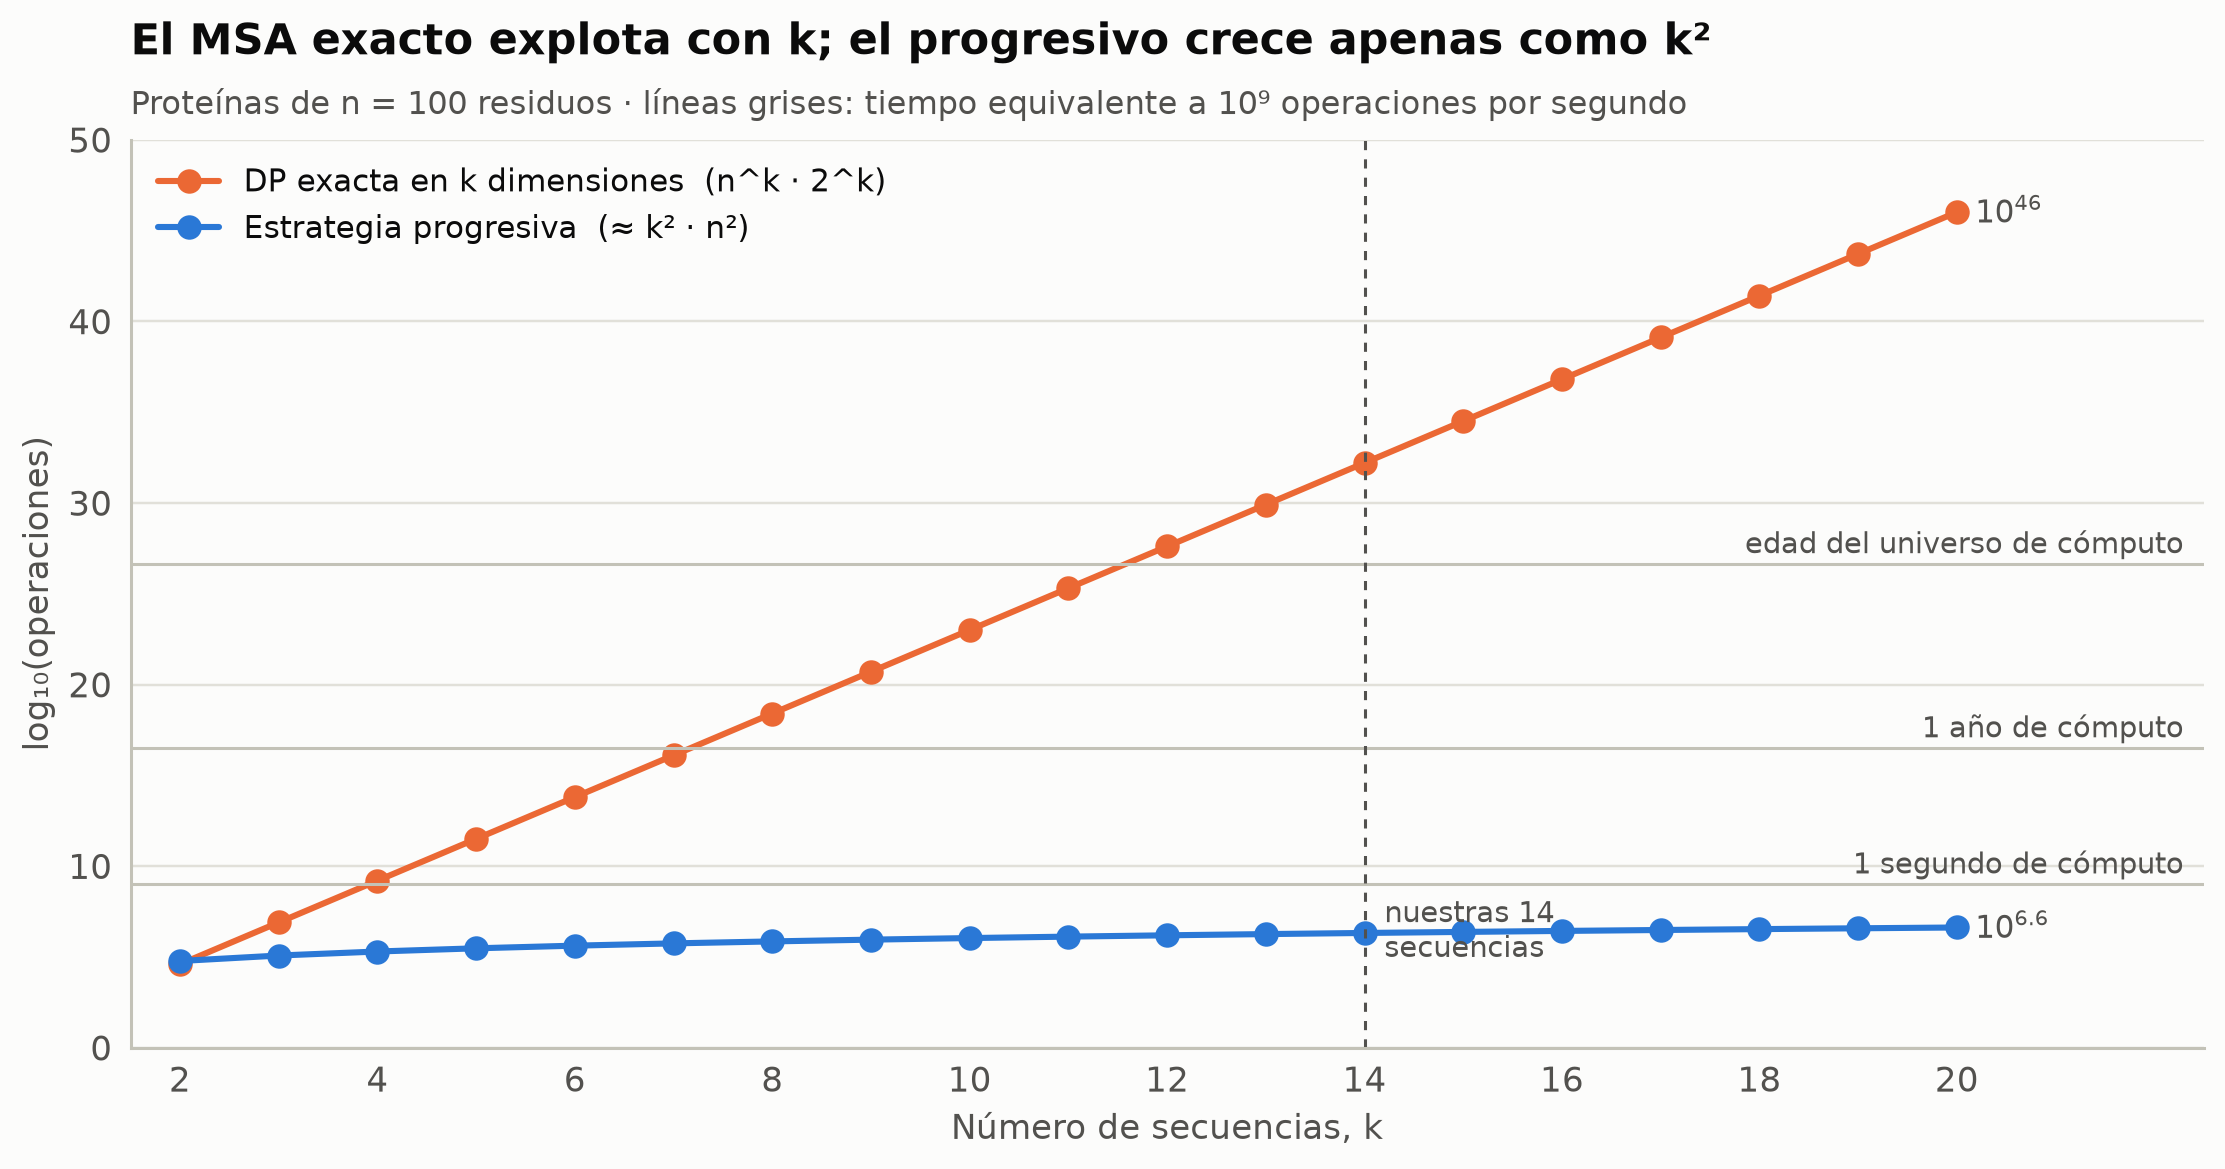

In [3]:
n = 100
ks = np.arange(2, 21)
log_ops = ks * np.log10(n) + ks * np.log10(2)                 # log10(n^k · 2^k)
log_prog = np.log10(ks**2 * n**2 + ks * n**2)                  # progresivo: k² pares + (k−1) fusiones
seconds_per_year = 3.15e7

fig, ax = plt.subplots(figsize=(10, 5.2))
ax.plot(ks, log_ops, "o-", color=ec.ORANGE, label="DP exacta en k dimensiones  (n^k · 2^k)")
ax.plot(ks, log_prog, "o-", color=ec.BLUE, label="Estrategia progresiva  (≈ k² · n²)")
for label, secs in [("1 segundo", 1), ("1 año", seconds_per_year), ("edad del universo", 13.8e9 * seconds_per_year)]:
    y = np.log10(secs * 1e9)                                  # a mil millones de operaciones por segundo
    ax.axhline(y, color=ec.BASELINE, lw=1)
    ax.text(22.3, y + 0.6, label + " de cómputo", color=ec.INK_2, fontsize=9.5, ha="right")
ec.label_end(ax, ks[-1], log_ops[-1], f"$10^{{{log_ops[-1]:.0f}}}$")
ec.label_end(ax, ks[-1], log_prog[-1], f"$10^{{{log_prog[-1]:.1f}}}$")
ax.axvline(14, color=ec.INK_2, lw=1, ls=(0, (3, 3)))
ax.text(14.2, 5, "nuestras 14\nsecuencias", color=ec.INK_2, fontsize=9.5)
ax.set_xlim(1.5, 22.5); ax.set_ylim(0, 50)
ax.set_xticks(ks[::2])
ax.set_xlabel("Número de secuencias, k")
ax.set_ylabel("log₁₀(operaciones)")
ax.legend(loc="upper left")
ec.title(ax, "El MSA exacto explota con k; el progresivo crece apenas como k²",
         "Proteínas de n = 100 residuos · líneas grises: tiempo equivalente a 10⁹ operaciones por segundo")
plt.show()

> 🔎 **Qué observamos.** En escala logarítmica el costo exacto es una **recta** con pendiente
> $\log_{10}(2n) \approx 2.3$: cada secuencia adicional multiplica el trabajo por **200**. Cruza la línea de "un año
> de cómputo" alrededor de $k = 8$ y la de "edad del universo" antes de $k = 12$. La estrategia progresiva (azul)
> ni se despega del suelo: ése es el precio que estamos dispuestos a pagar, **renunciar a la garantía de óptimo** a
> cambio de poder alinear miles de secuencias.

### El caso exacto que sí podemos resolver: tres secuencias

Con $k = 3$ y secuencias cortas el cubo cabe en memoria. Programémoslo, para ver la recurrencia funcionando y para
tener un **óptimo verdadero** contra el cual comparar la heurística más adelante. Usaremos BLOSUM62 y un hueco lineal
de $-8$ por cada par residuo–hueco (lo explicamos en detalle en la sección 4).

In [4]:
GAP = -8.0            # costo de cada par residuo–hueco en toda la lección (salvo donde se diga lo contrario)

def pair_score(x, y, gap=GAP):
    """Puntaje de un par de símbolos: BLOSUM62, hueco contra residuo = gap, hueco contra hueco = 0."""
    if x == "-" and y == "-":
        return 0.0
    if x == "-" or y == "-":
        return gap
    return float(BLOSUM62[x, y])

def sp_column(column, gap=GAP):
    """Suma de pares de una columna (lista de símbolos)."""
    return sum(pair_score(x, y, gap) for x, y in itertools.combinations(column, 2))

def exact_msa3(a, b, c, gap=GAP):
    """MSA óptimo (puntaje SP) de tres secuencias por programación dinámica en un cubo."""
    n1, n2, n3 = len(a), len(b), len(c)
    F = np.full((n1 + 1, n2 + 1, n3 + 1), -np.inf); F[0, 0, 0] = 0
    back = np.zeros((n1 + 1, n2 + 1, n3 + 1, 3), dtype=np.int8)
    moves = [d for d in itertools.product((0, 1), repeat=3) if any(d)]      # las 7 vecinas
    for i in range(n1 + 1):
        for j in range(n2 + 1):
            for k in range(n3 + 1):
                for d in moves:
                    pi, pj, pk = i - d[0], j - d[1], k - d[2]
                    if pi < 0 or pj < 0 or pk < 0:
                        continue
                    col = (a[i - 1] if d[0] else "-", b[j - 1] if d[1] else "-", c[k - 1] if d[2] else "-")
                    v = F[pi, pj, pk] + sp_column(col, gap)
                    if v > F[i, j, k]:
                        F[i, j, k] = v; back[i, j, k] = d
    rows, (i, j, k) = ["", "", ""], (n1, n2, n3)
    while (i, j, k) != (0, 0, 0):
        d = back[i, j, k]
        rows[0] = (a[i - 1] if d[0] else "-") + rows[0]
        rows[1] = (b[j - 1] if d[1] else "-") + rows[1]
        rows[2] = (c[k - 1] if d[2] else "-") + rows[2]
        i, j, k = i - d[0], j - d[1], k - d[2]
    return rows, F[n1, n2, n3]

# Tres fragmentos reales: del inicio del citocromo c hasta el final del motivo C..CH (humano, levadura, Arabidopsis)
def to_motif(s):
    return s[:s.find("CH", 10) + 2]
frag = {sp: to_motif(seqs[names.index(sp)]) for sp in ["Humano", "Levadura", "Arabidopsis"]}
t0 = time.perf_counter()
rows3, best3 = exact_msa3(*frag.values())
print(f"Cubo de {np.prod([len(s) + 1 for s in frag.values()]):,} celdas resuelto en {time.perf_counter() - t0:.2f} s")
for name, row in zip(frag, rows3):
    print(f"  {name:12s} {row}")
print(f"Puntaje SP óptimo = {best3:.0f}")

Cubo de 14,000 celdas resuelto en 0.11 s
  Humano       M--------GDVEKGKKIFIMKCSQCH
  Levadura     MTEF-KA--GSAKKGATLFKTRCLQCH
  Arabidopsis  MASFDEAPPGNAKAGEKIFRTKCAQCH
Puntaje SP óptimo = 77


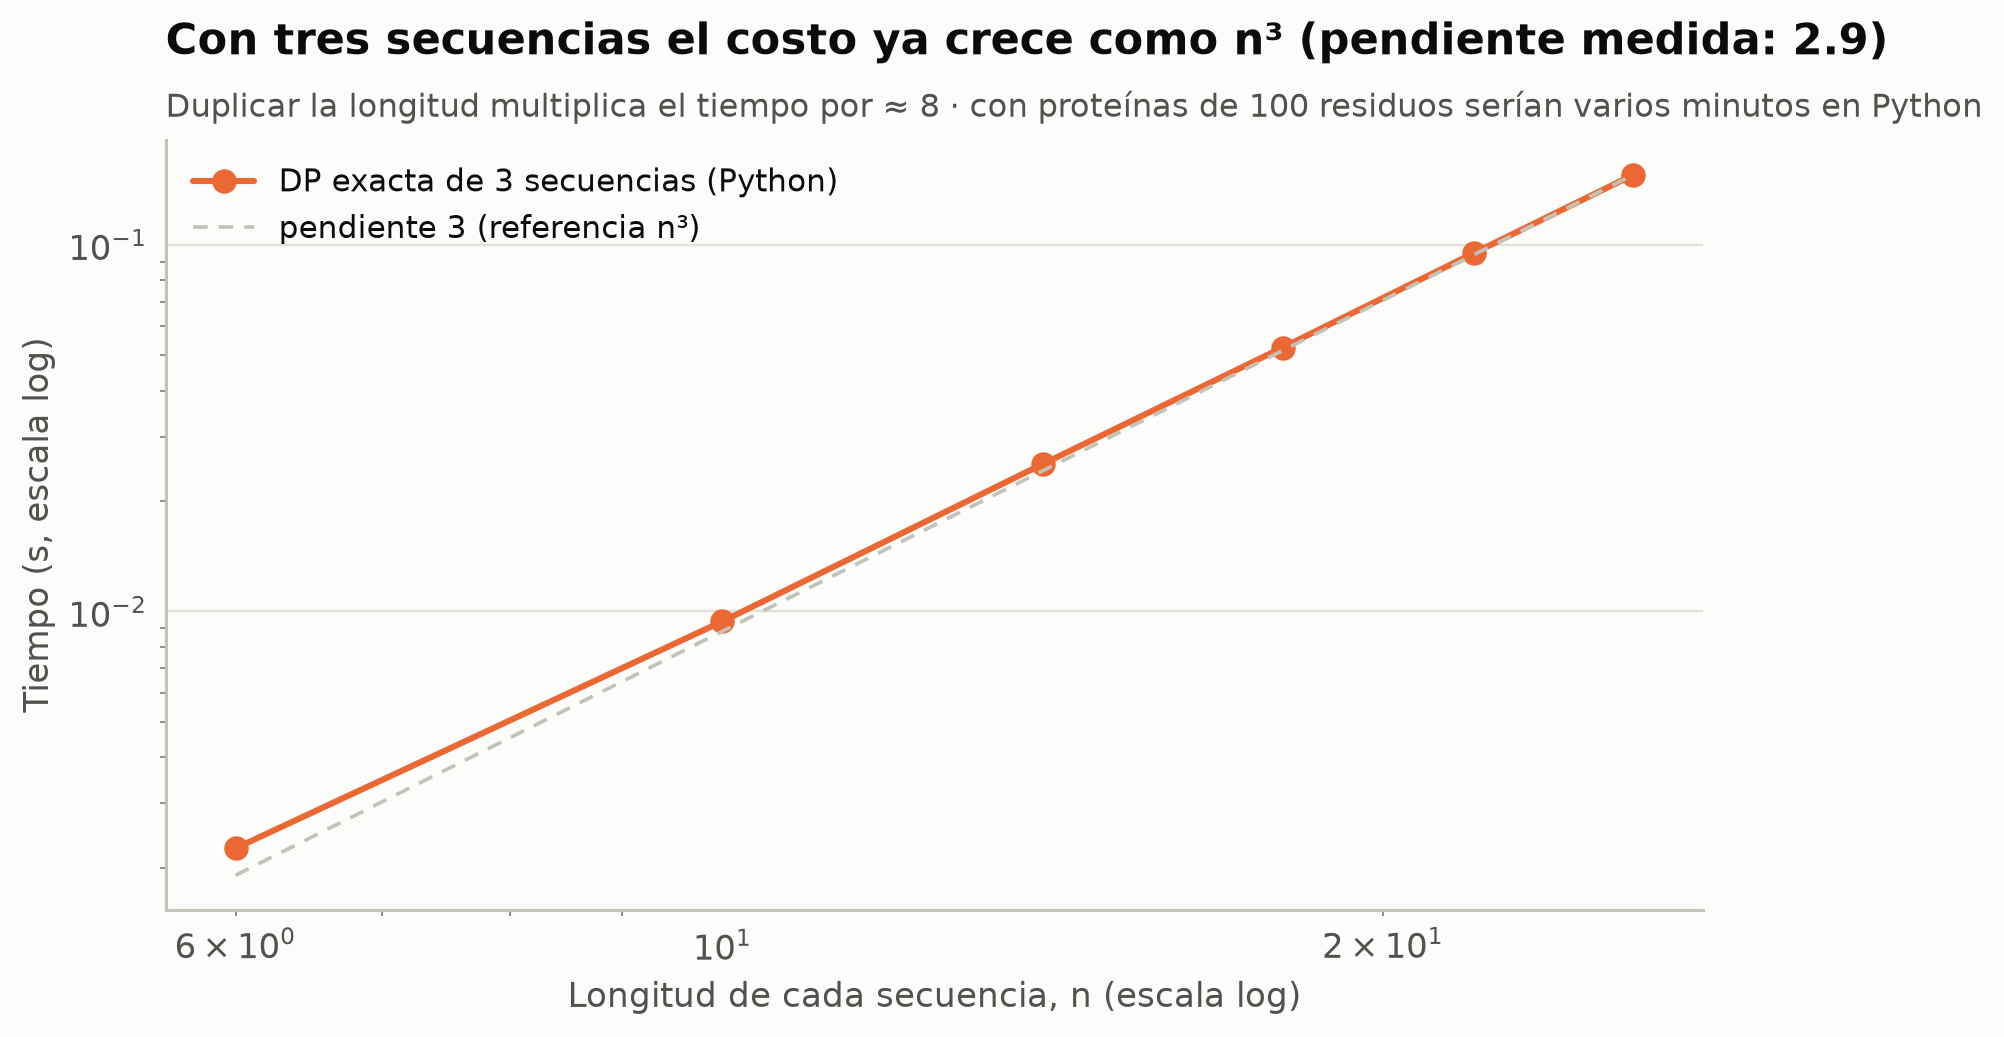

In [5]:
timing = []
rng = np.random.default_rng(41)
for L in [6, 10, 14, 18, 22, 26]:
    triple = ["".join(rng.choice(list(AA), L)) for _ in range(3)]
    runs = []
    for _ in range(2):                                        # mejor de dos: menos ruido
        t0 = time.perf_counter(); exact_msa3(*triple); runs.append(time.perf_counter() - t0)
    timing.append((L, min(runs)))
timing = pd.DataFrame(timing, columns=["n", "segundos"])
slope = np.polyfit(np.log10(timing.n[1:]), np.log10(timing.segundos[1:]), 1)[0]

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.loglog(timing.n, timing.segundos, "o-", color=ec.ORANGE, label="DP exacta de 3 secuencias (Python)")
ref = timing.segundos.iloc[-1] * (timing.n / timing.n.iloc[-1]) ** 3
ax.loglog(timing.n, ref, color=ec.BASELINE, lw=1.2, ls=(0, (4, 3)), label="pendiente 3 (referencia n³)")
ax.set_xlabel("Longitud de cada secuencia, n (escala log)")
ax.set_ylabel("Tiempo (s, escala log)")
ax.legend(loc="upper left")
ec.title(ax, f"Con tres secuencias el costo ya crece como n³ (pendiente medida: {slope:.1f})",
         "Duplicar la longitud multiplica el tiempo por ≈ 8 · con proteínas de 100 residuos serían varios minutos en Python")
plt.show()

> 🔎 **Qué observamos.** El alineamiento exacto de los tres extremos N-terminales pone los huecos **al principio**
> de la secuencia humana: las extensiones de levadura y Arabidopsis no tienen pareja en los vertebrados. Y el tiempo
> crece con pendiente ≈ 3 en escala log–log, tal como predice $n^k$ con $k = 3$. Cada secuencia extra sube la
> pendiente en uno.

✅ **Compruebe su comprensión.** ¿Cuántas vecinas tiene cada celda del hipercubo con $k = 4$? ¿Y cuántas celdas
tendría el hipercubo para cuatro secuencias de 110 residuos?

## 4. ¿Cómo se puntúa un MSA? La suma de pares (SP)

Para dos secuencias, el puntaje de una columna era $s(a, b)$, tomado de BLOSUM62. Con $k$ secuencias, una columna
tiene $k$ símbolos. La idea más usada (Carrillo y Lipman, 1988; Altschul, 1989) es sencilla: **sumar el puntaje de
todos los pares** que se pueden formar dentro de la columna, como si cada par de secuencias "votara" por esa columna.

$$
\operatorname{SP}(\text{columna } c) \;=\; \sum_{p < q} s\big(x_{p c},\, x_{q c}\big),
\qquad
\operatorname{SP}(\text{MSA}) \;=\; \sum_{c=1}^{L} \operatorname{SP}(c),
\qquad
s(x, y) =
\begin{cases}
\text{BLOSUM62}(x, y) & \text{dos residuos}\\
g & \text{residuo contra hueco}\\
0 & \text{hueco contra hueco}
\end{cases}
$$

| Símbolo | Significado | Valor en esta clase |
|---|---|---|
| $x_{pc}$ | símbolo (residuo o `-`) de la secuencia $p$ en la columna $c$ | — |
| $p < q$ | recorre cada par de secuencias una sola vez: $\binom{k}{2}$ pares | 6 pares si $k=4$ |
| $s(x,y)$ | puntaje de un par de símbolos | BLOSUM62 |
| $g$ | castigo por enfrentar un residuo con un hueco | $-8$ |
| $L$ | número de columnas del MSA | — |

El par hueco–hueco vale 0 porque, para esas dos secuencias, la columna **no existe**: en su alineamiento por pares
esa columna simplemente desaparecería.

### Ejemplo a mano

Cuatro fragmentos cortos ya alineados:

```
S1  G K K I F
S2  G K R I F
S3  G - K V F
S4  G A K I Y
```

| Columna | Símbolos | Pares (6 por columna) | SP |
|---|---|---|---|
| 1 | G G G G | 6 × BLOSUM(G,G) = 6 × 6 | **36** |
| 2 | K K − A | (K,K)=5 · (K,−)=−8 · (K,A)=−1 · (K,−)=−8 · (K,A)=−1 · (−,A)=−8 | **−21** |
| 3 | K R K K | 3 × (K,K)=5 + 3 × (K,R)=2 | **21** |
| 4 | I I V I | 3 × (I,I)=4 + 3 × (I,V)=3 | **21** |
| 5 | F F F Y | 3 × (F,F)=6 + 3 × (F,Y)=3 | **27** |
| | | **Total** | **84** |

Fíjese en la columna 2: un solo hueco participa en **tres** pares y cuesta $3 \times (-8) = -24$. En un MSA de $k$
secuencias, un hueco en una fila se castiga $k - 1$ veces.

In [6]:
toy = ["GKKIF", "GKRIF", "G-KVF", "GAKIY"]

def sp_score(rows, gap=GAP):
    """Puntaje suma de pares de un MSA completo (lista de filas de igual longitud)."""
    return sum(sp_column([r[c] for r in rows], gap) for c in range(len(rows[0])))

for c in range(len(toy[0])):
    col = [r[c] for r in toy]
    print(f"columna {c + 1}: {' '.join(col)}   SP = {sp_column(col):6.0f}")
print(f"SP total = {sp_score(toy):.0f}")

columna 1: G G G G   SP =     36
columna 2: K K - A   SP =    -21
columna 3: K R K K   SP =     21
columna 4: I I V I   SP =     21
columna 5: F F F Y   SP =     27
SP total = 84


> 🔎 **Qué observamos.** El código reproduce la cuenta a mano. Las columnas **idénticas** (1) o con sustituciones
> **conservadoras** (3: K↔R, 4: I↔V, 5: F↔Y, todas con puntaje positivo en BLOSUM62) suman; la columna con un hueco
> resta mucho.

### Las debilidades del puntaje SP

La suma de pares es práctica pero tiene dos problemas que conviene conocer:

1. **Redundancia.** Si en el MSA hay siete vertebrados casi idénticos y un solo hongo, los $\binom{7}{2} = 21$ pares
   de vertebrados dominan la suma: la columna "vota" como quieren los vertebrados. CLUSTAL W (Thompson, Higgins y
   Gibson, 1994) corrige esto dando **pesos** menores a las secuencias muy parecidas entre sí.
2. **No es evolutivo.** Una mutación ocurrida una vez en el ancestro de un grupo se cuenta muchas veces (una por
   cada par que la ve). La suma de pares cuenta **pares de diferencias**, no **eventos** evolutivos.

A pesar de ello es la función objetivo más usada para **comparar** alineamientos, y la usaremos en toda la clase.

✅ **Compruebe su comprensión.** Con $k = 10$ secuencias, ¿cuántos pares suma cada columna? Si una sola secuencia
tiene un hueco en una columna donde las otras nueve tienen residuos, ¿cuánto cuesta ese hueco con $g = -8$?

## 5. La estrategia progresiva de Feng y Doolittle

Si no podemos alinear todo a la vez, alineemos **de a dos**. En 1987 Da-Fei Feng y Russell Doolittle propusieron la
idea que, con muchas mejoras, sigue detrás de CLUSTAL, MAFFT, MUSCLE y T-Coffee: construir el MSA **poco a poco**,
empezando por las secuencias más parecidas, como quien arma un rompecabezas empezando por las piezas que encajan
sin duda.

| Paso | Qué se hace | Costo aproximado |
|---|---|---|
| 1. Distancias | alinear **cada par** de secuencias y medir cuán distintas son | $\binom{k}{2}$ alineamientos de $O(n^2)$ |
| 2. Árbol guía | agrupar las secuencias por parecido (UPGMA o *neighbor joining*) | $O(k^3)$ o menos |
| 3. Alineamiento progresivo | recorrer el árbol desde las hojas hacia la raíz, alineando **grupos contra grupos** | $k-1$ fusiones de $O(n^2)$ |

La regla de oro del paso 3 es: **"una vez hueco, siempre hueco"** (*once a gap, always a gap*). Cuando dos grupos
ya alineados se fusionan, el alineamiento interno de cada grupo **no se toca**: sólo se insertan columnas de huecos
completas. Eso hace al método rápido y estable, pero también **irreversible**: un error cometido al principio (entre
secuencias muy parecidas, donde casi nunca hay errores) no se puede corregir después, cuando llegan las secuencias
lejanas. Por eso se empieza por las más parecidas.

## 6. Paso 1: distancias por pares

Alineamos globalmente cada par con BLOSUM62 y huecos afines (Lección 3.3) y calculamos la **distancia p**: la
fracción de posiciones alineadas (sin contar huecos) en las que los residuos son distintos.

$$
d_{pq} \;=\; 1 - \frac{\text{posiciones idénticas}}{\text{posiciones alineadas sin hueco}}
$$

| Símbolo | Significado |
|---|---|
| $d_{pq}$ | distancia entre las secuencias $p$ y $q$ (0 = idénticas, 1 = nada en común) |
| posiciones alineadas | columnas del alineamiento por pares donde ninguna de las dos tiene hueco |

Con 14 secuencias son $\binom{14}{2} = 91$ alineamientos por pares, cosa de milisegundos para Biopython.

In [7]:
pair_aligner = PairwiseAligner(mode="global", substitution_matrix=BLOSUM62,
                               open_gap_score=-10, extend_gap_score=-0.5)

def p_distance(a, b):
    """Distancia p a partir del alineamiento global óptimo de dos secuencias."""
    aln = pair_aligner.align(a, b)[0]
    cols = [(x, y) for x, y in zip(aln[0], aln[1]) if x != "-" and y != "-"]
    return 1 - sum(x == y for x, y in cols) / len(cols)

def distance_matrix(seq_list):
    k = len(seq_list); D = np.zeros((k, k))
    for i, j in itertools.combinations(range(k), 2):
        D[i, j] = D[j, i] = p_distance(seq_list[i], seq_list[j])
    return D

t0 = time.perf_counter()
D = distance_matrix(seqs)
print(f"{len(seqs) * (len(seqs) - 1) // 2} alineamientos por pares en {time.perf_counter() - t0:.2f} s")
pd.DataFrame(D, index=names, columns=names).round(2)

91 alineamientos por pares en 0.01 s


,Humano,Ratón,Caballo,Pollo,Rana,Pez cebra,Atún,Mosca,Gusano (C. elegans),Levadura,Neurospora,Arabidopsis,Arroz,Chlamydomonas
Humano,0.00,0.09,0.11,0.12,0.14,0.15,0.19,0.32,0.41,0.36,0.37,0.36,0.34,0.35
Ratón,0.09,0.00,0.06,0.08,0.11,0.09,0.14,0.27,0.39,0.36,0.35,0.36,0.36,0.31
Caballo,0.11,0.06,0.00,0.10,0.13,0.13,0.16,0.29,0.39,0.37,0.35,0.39,0.37,0.34
Pollo,0.12,0.08,0.10,0.00,0.13,0.11,0.15,0.30,0.39,0.37,0.36,0.38,0.37,0.34
Rana,0.14,0.11,0.13,0.13,0.00,0.12,0.16,0.32,0.39,0.38,0.38,0.38,0.38,0.36
Pez cebra,0.15,0.09,0.13,0.11,0.12,0.00,0.07,0.29,0.38,0.38,0.37,0.38,0.38,0.35
Atún,0.19,0.14,0.16,0.15,0.16,0.07,0.00,0.31,0.43,0.37,0.36,0.39,0.38,0.38
Mosca,0.32,0.27,0.29,0.30,0.32,0.29,0.31,0.00,0.43,0.40,0.43,0.37,0.42,0.36
Gusano (C. elegans),0.41,0.39,0.39,0.39,0.39,0.38,0.43,0.43,0.00,0.50,0.48,0.45,0.43,0.42
Levadura,0.36,0.36,0.37,0.37,0.38,0.38,0.37,0.40,0.50,0.00,0.32,0.40,0.41,0.44


> 🔎 **Qué observamos.** Humano, ratón y caballo difieren en menos del 10 % de las posiciones; entre un vertebrado y
> una planta la distancia sube a ≈ 0.35–0.40. Aun así, **más de la mitad de los residuos son idénticos** entre
> organismos separados por más de mil millones de años: el citocromo *c* está muy restringido por su función.

## 7. Paso 2: el árbol guía con UPGMA

**UPGMA** (*Unweighted Pair Group Method with Arithmetic mean*, Sokal y Michener, 1958) es el método de agrupamiento
más simple:

1. Buscar en la matriz el par de grupos $A$, $B$ con la **distancia más pequeña** y unirlos en un grupo nuevo $AB$.
2. Calcular la distancia del grupo nuevo a cada grupo restante $C$ como el **promedio** de las distancias entre
   todos sus miembros:

$$
d(AB,\, C) \;=\; \frac{|A|\, d(A, C) \;+\; |B|\, d(B, C)}{|A| + |B|}
$$

3. Repetir hasta que quede un solo grupo.

| Símbolo | Significado |
|---|---|
| $A, B, C$ | grupos de secuencias (al principio, cada secuencia es un grupo) |
| $\lvert A\rvert$ | número de secuencias en el grupo $A$ |
| $d(A, C)$ | distancia promedio entre los miembros de $A$ y los de $C$ |

### UPGMA a mano con cinco especies

Con las distancias reales redondeadas a dos decimales:

| | Humano | Pollo | Mosca | Levadura | Arabidopsis |
|---|---|---|---|---|---|
| **Humano** | 0 | **0.12** | 0.32 | 0.36 | 0.36 |
| **Pollo** | | 0 | 0.30 | 0.37 | 0.38 |
| **Mosca** | | | 0 | 0.40 | 0.37 |
| **Levadura** | | | | 0 | 0.40 |

* **Fusión 1.** El mínimo es Humano–Pollo = 0.12 → grupo (H,P).
  $d\big((H,P), \text{Mosca}\big) = (0.32 + 0.30)/2 = 0.31$;
  $d\big((H,P), \text{Lev}\big) = (0.36 + 0.37)/2 = 0.365$;
  $d\big((H,P), \text{Arab}\big) = (0.36 + 0.38)/2 = 0.37$.
* **Fusión 2.** El mínimo es ahora (H,P)–Mosca = 0.31 → grupo (H,P,M).
  $d\big((H,P,M), \text{Lev}\big) = (2 \times 0.365 + 0.40)/3 \approx 0.377$;
  $d\big((H,P,M), \text{Arab}\big) = (2 \times 0.37 + 0.37)/3 = 0.37$.
* **Fusión 3.** Mínimo: (H,P,M)–Arabidopsis = 0.37 (¡por muy poco frente a 0.377!).
* **Fusión 4.** Se une la levadura al final.

El resultado agrupa a la planta con los animales **antes** que al hongo, aunque sabemos que los hongos son
parientes más cercanos de los animales. No es un error del cálculo: UPGMA supone que todas las ramas evolucionan
a la misma velocidad (un "reloj molecular"), y la levadura ha acumulado cambios más rápido. **Un árbol guía no es
un árbol filogenético**: sólo tiene que ordenar las fusiones de modo razonable. Las filogenias de verdad las
construiremos en el Módulo 5.

Programemos UPGMA y verifiquemos contra SciPy (`linkage(..., method="average")` es exactamente UPGMA).

In [8]:
def upgma(D, verbose_names=None):
    """UPGMA. Devuelve una matriz de enlace estilo SciPy: [grupo_i, grupo_j, distancia, tamaño]."""
    k = len(D)
    members = {i: [i] for i in range(k)}
    dist = {(i, j): D[i, j] for i in range(k) for j in range(k) if i != j}
    active, Z, steps = list(range(k)), [], []
    for new in range(k, 2 * k - 1):
        d_min, a, b = min((dist[a, b], a, b) for a, b in itertools.combinations(active, 2))
        Z.append([a, b, d_min, len(members[a]) + len(members[b])])
        members[new] = members[a] + members[b]
        active = [c for c in active if c not in (a, b)]
        for c in active:
            v = (len(members[a]) * dist[a, c] + len(members[b]) * dist[b, c]) / len(members[new])
            dist[new, c] = dist[c, new] = v
        steps.append(dict(a=a, b=b, d=d_min, active=active + [new], dist=dict(dist), members=dict(members)))
        active.append(new)
    return np.array(Z, dtype=float), steps

sub = [names.index(s) for s in ["Humano", "Pollo", "Mosca", "Levadura", "Arabidopsis"]]
sub_names = [names[i] for i in sub]
Z5, steps5 = upgma(D[np.ix_(sub, sub)])
for s in steps5:
    grp = lambda g: "(" + ",".join(sub_names[m][:4] for m in s["members"][g]) + ")"
    print(f"fusión: {grp(s['a']):28s} + {grp(s['b']):14s} a distancia {s['d']:.3f}")

Z, _ = upgma(D)
Z_scipy = linkage(squareform(D, checks=False), method="average")
print("\n¿Mismas alturas de fusión que SciPy?", np.allclose(Z[:, 2], Z_scipy[:, 2]))

fusión: (Huma)                       + (Poll)         a distancia 0.124
fusión: (Mosc)                       + (Huma,Poll)    a distancia 0.311
fusión: (Arab)                       + (Mosc,Huma,Poll) a distancia 0.371
fusión: (Leva)                       + (Arab,Mosc,Huma,Poll) a distancia 0.381

¿Mismas alturas de fusión que SciPy? True


> 🔎 **Qué observamos.** Nuestra implementación reproduce paso a paso la cuenta a mano y coincide con SciPy. La
> matriz de enlace `Z` tiene una fila por fusión: los dos grupos que se unen, la distancia a la que se unen y el
> tamaño del grupo nuevo. Los grupos nuevos reciben números a partir de $k$ (aquí 5, 6, 7, 8): es el formato
> estándar de SciPy y el que usaremos para dibujar y para guiar el alineamiento.

### 🎬 UPGMA paso a paso

En la animación, a la izquierda está la matriz de distancias **de los grupos que siguen activos**; el recuadro negro
marca el mínimo. A la derecha el árbol crece con cada fusión.

![Vista previa: UPGMA fusiona los dos grupos más cercanos y promedia sus distancias, paso a paso](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-04-msa-motivos-hmm/4.1_upgma.gif)

*Vista previa: UPGMA fusiona los dos grupos más cercanos y promedia sus distancias, paso a paso*

In [9]:
def tree_layout(Z, k):
    """Coordenadas de un árbol horizontal: hojas en el eje y (orden del dendrograma), altura en x."""
    order = dendrogram(Z, no_plot=True)["leaves"]
    y = {leaf: pos for pos, leaf in enumerate(order)}
    x = {leaf: 0.0 for leaf in range(k)}
    for step, (a, b, h, _) in enumerate(Z):
        node = k + step
        y[node] = (y[int(a)] + y[int(b)]) / 2; x[node] = h
    return order, x, y

def draw_tree(ax, Z, labels, upto=None, highlight=None, label_colors=None, fs=10.5, lw=2):
    """Dibuja el árbol hasta la fusión `upto` (todas por defecto); `highlight` resalta una fusión."""
    k = len(labels); upto = len(Z) if upto is None else upto
    order, x, y = tree_layout(Z, k)
    for step in range(upto):
        a, b, h, _ = Z[step]; a, b = int(a), int(b)
        color = ec.ORANGE if step == highlight else ec.INK_2
        width = lw * 1.8 if step == highlight else lw
        ax.plot([x[a], h, h, x[b]], [y[a], y[a], y[b], y[b]], color=color, lw=width, solid_capstyle="round")
    for leaf in range(k):
        color = (label_colors or {}).get(labels[leaf], ec.INK)
        ax.text(-0.012 * max(Z[:, 2].max(), 0.01) * 3, y[leaf], labels[leaf], ha="right", va="center",
                fontsize=fs, color=color, fontweight="bold" if label_colors else "normal")
        ax.plot(0, y[leaf], "o", color=ec.INK_2, ms=4)
    ax.set_ylim(k - 0.5, -0.5)
    ax.set_yticks([]); ax.spines["left"].set_visible(False); ax.grid(False)
    ax.set_xlabel("distancia de fusión (UPGMA)")
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))
    ax.set_xticks([t for t in ax.get_xticks() if t >= 0])
    return order

D5 = D[np.ix_(sub, sub)]
frames_u = []
for s in range(len(Z5)):
    frames_u += [(s, "min"), (s, "merged")]
frames_u += [(len(Z5) - 1, "merged")] * 3

fig, (ax_m, ax_t) = plt.subplots(1, 2, figsize=(12.5, 5.4), width_ratios=[1, 1.15])
fig.subplots_adjust(wspace=0.45)

def group_name(g, members):
    return "+".join(sub_names[m][:3] for m in members[g])

def update(f):
    ax_m.clear(); ax_t.clear()
    s, phase = frames_u[f]
    info = steps5[s]
    if phase == "min":           # matriz ANTES de la fusión s
        members = steps5[s - 1]["members"] if s else {i: [i] for i in range(5)}
        active = steps5[s - 1]["active"] if s else list(range(5))
        dist = steps5[s - 1]["dist"] if s else {(i, j): D5[i, j] for i in range(5) for j in range(5) if i != j}
    else:                        # matriz DESPUÉS de la fusión s
        members, active, dist = info["members"], info["active"], info["dist"]
    m = len(active)
    M = np.array([[0 if a == b else dist[a, b] for b in active] for a in active])
    ax_m.imshow(M, cmap="curso_seq", vmin=0, vmax=0.45)
    labels = [group_name(g, members) for g in active]
    for i in range(m):
        for j in range(m):
            ax_m.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=10.5,
                      color=ec.SURFACE if M[i, j] > 0.3 else ec.INK)
    if phase == "min":
        i, j = active.index(info["a"]), active.index(info["b"])
        for (r, c) in [(i, j), (j, i)]:
            ax_m.add_patch(Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor=ec.INK, lw=3))
        msg = f"Mínimo: {group_name(info['a'], members)} con {group_name(info['b'], members)} = {info['d']:.3f}"
    else:
        msg = f"Fusión {s + 1}: distancias promediadas"
    ax_m.set_xticks(range(m)); ax_m.set_xticklabels(labels, rotation=35, ha="right", fontsize=9.5)
    ax_m.set_yticks(range(m)); ax_m.set_yticklabels(labels, fontsize=9.5)
    ax_m.grid(False)
    ax_m.set_title(msg, loc="left", fontsize=10.5)
    upto = s + (1 if phase == "merged" else 0)
    draw_tree(ax_t, Z5, sub_names, upto=upto, highlight=s if phase == "merged" else None, fs=11)
    ax_t.set_xlim(-0.12, 0.42)
    ax_t.set_title(f"Árbol guía: {upto} de {len(Z5)} fusiones", loc="left", fontsize=11.5)
    return ()

ec.animate(fig, update, frames=len(frames_u), interval=1100, name="4.1_upgma")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** En cada paso la matriz **se achica en una fila y una columna**: dos grupos desaparecen y
> aparece uno nuevo cuyas distancias son promedios. La altura a la que se dibuja cada unión es la distancia de
> fusión, que nunca disminuye de un paso al siguiente.

### El árbol guía completo

Apliquemos lo mismo a las 14 especies. Coloreamos cada nombre según su grupo taxonómico.

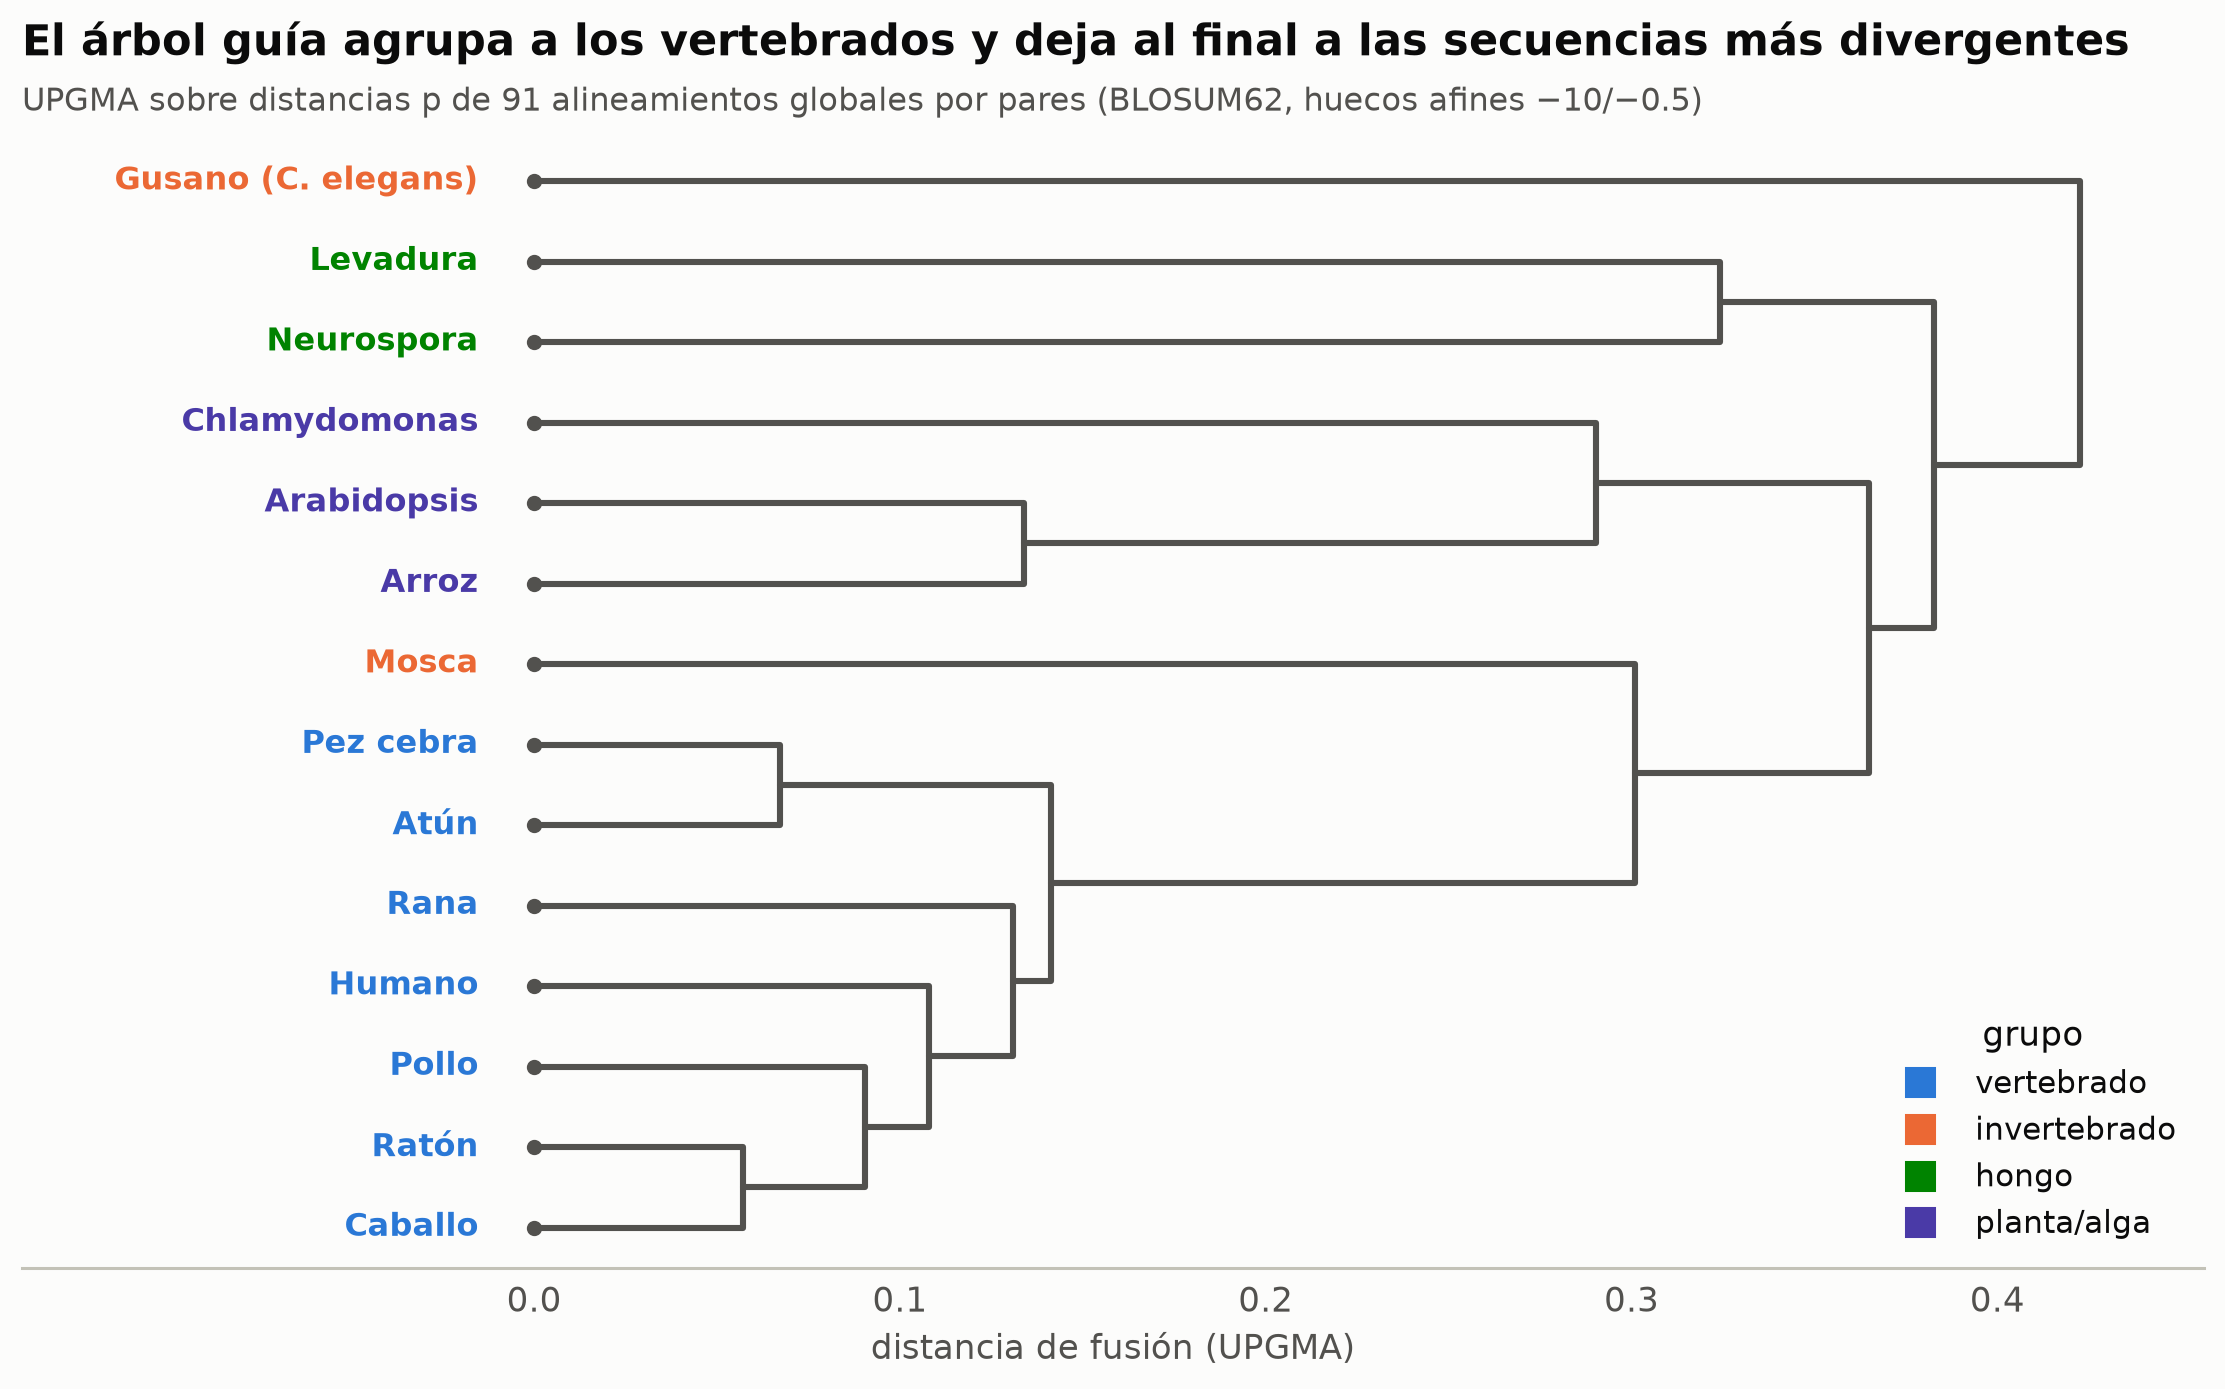

Orden de las hojas (lo usaremos para ordenar las filas del MSA): ['Gusano (C. elegans)', 'Levadura', 'Neurospora', 'Chlamydomonas', 'Arabidopsis', 'Arroz', 'Mosca', 'Pez cebra', 'Atún', 'Rana', 'Humano', 'Pollo', 'Ratón', 'Caballo']


In [10]:
name_colors = {n: GROUP_COLOR[GROUP[n]] for n in names}
fig, ax = plt.subplots(figsize=(10, 6.2))
leaf_order = draw_tree(ax, Z, names, label_colors=name_colors, fs=10.5)
ax.set_xlim(-0.14, Z[:, 2].max() * 1.08)
for g, c in GROUP_COLOR.items():
    ax.plot([], [], "s", color=c, label=g, ms=9)
ax.legend(loc="lower right", ncol=1, title="grupo")
ax.set_title("")
ec.title(ax, "El árbol guía agrupa a los vertebrados y deja al final a las secuencias más divergentes",
         "UPGMA sobre distancias p de 91 alineamientos globales por pares (BLOSUM62, huecos afines −10/−0.5)")
plt.show()
print("Orden de las hojas (lo usaremos para ordenar las filas del MSA):", [names[i] for i in leaf_order])

> 🔎 **Qué observamos.** Los vertebrados se unen primero (distancias < 0.15), aunque el orden interno no respeta la
> taxonomía: el pollo se une a ratón y caballo **antes** que el humano, cuyo citocromo *c* tiene algunas sustituciones
> propias. Las dos plantas se unen entre sí, y los dos hongos también; el gusano, la secuencia más divergente, queda
> para el final. De nuevo: un árbol guía sólo ordena las fusiones, no pretende ser una filogenia. El orden de fusión que seguirá el alineamiento progresivo es
> exactamente el orden de las uniones de este árbol: de izquierda (las hojas) a derecha (la raíz), de menor a mayor
> distancia de fusión.

✅ **Compruebe su comprensión.** Mire el árbol: ¿cuál será la **primera** fusión del alineamiento progresivo? ¿Y la
**última**? ¿Por qué conviene que las últimas fusiones sean entre grupos grandes y no entre una secuencia sola y
todas las demás?

## 8. Paso 3: alinear perfiles contra perfiles

Cuando el árbol dice "une el grupo $A$ con el grupo $B$", cada grupo ya es un pequeño MSA. Resumimos cada columna de
un grupo como un **perfil**: la fracción de cada símbolo (20 aminoácidos + hueco) en esa columna. Luego alineamos
los dos perfiles con **la misma programación dinámica de la Lección 3.2**; lo único que cambia es cómo se puntúa
enfrentar la columna $u$ de $A$ con la columna $v$ de $B$: el **promedio** de todos los pares que se forman entre
ellas, que es justamente la parte de la suma de pares que "cruza" de un grupo al otro.

$$
S(u, v) \;=\; \frac{1}{|A|\,|B|} \sum_{x \in u} \sum_{y \in v} s(x, y)
\;=\; \mathbf f_u^{\top}\, \mathbf S\, \mathbf f_v ,
\qquad
G(u) \;=\; g \,\big(1 - f_u(-)\big)
$$

$$
F(i, j) = \max \begin{cases}
F(i-1, j-1) + S(u_i, v_j) & \text{alinear la columna } u_i \text{ con } v_j\\
F(i-1, j) + G(u_i) & \text{columna } u_i \text{ contra una columna nueva de huecos en } B\\
F(i, j-1) + G(v_j) & \text{columna nueva de huecos en } A \text{ contra } v_j
\end{cases}
$$

| Símbolo | Significado |
|---|---|
| $u_i$, $v_j$ | columna $i$ del perfil $A$ y columna $j$ del perfil $B$ |
| $\lvert A\rvert$, $\lvert B\rvert$ | número de secuencias en cada grupo |
| $\mathbf f_u$ | vector de 21 frecuencias de la columna $u$ (20 aminoácidos + hueco), suma 1 |
| $\mathbf S$ | matriz $21 \times 21$: BLOSUM62 ampliada con $g$ para residuo–hueco y 0 para hueco–hueco |
| $G(u)$ | costo de enfrentar la columna $u$ con huecos: $g$ por cada residuo (no por cada hueco) de $u$ |
| $F(i,j)$ | mejor puntaje alineando las primeras $i$ columnas de $A$ con las primeras $j$ de $B$ |

### Ejemplo a mano

Grupo $A$ = {`K`, `R`} (una columna), grupo $B$ = {`K`, `K`, `-`}:

* Por pares: $(K,K)=5,\ (K,K)=5,\ (K,-)=-8,\ (R,K)=2,\ (R,K)=2,\ (R,-)=-8$. Suma $= -2$, entre $2 \times 3 = 6$
  pares: $S(u,v) = -0.33$.
* Con frecuencias: $\mathbf f_u = (K{:}\ ½,\ R{:}\ ½)$, $\mathbf f_v = (K{:}\ ⅔,\ -{:}\ ⅓)$.
  $S = ½\,(⅔ \cdot 5 + ⅓ \cdot (-8)) + ½\,(⅔ \cdot 2 + ⅓ \cdot (-8)) = ½(0.67) + ½(-1.33) = -0.33$. ✔

La forma con frecuencias es la que usan los programas: en lugar de recorrer todos los pares, multiplica dos vectores
por una matriz, y con `numpy` calculamos **todas** las parejas de columnas de una vez: $F_A\,\mathbf S\,F_B^{\top}$.

In [11]:
SYMBOLS = AA + "-"
SYM_IDX = {c: i for i, c in enumerate(SYMBOLS)}

def extended_matrix(gap=GAP):
    """BLOSUM62 ampliada a 21×21: la fila/columna 21 es el hueco."""
    S = np.zeros((21, 21))
    for a in AA:
        for b in AA:
            S[SYM_IDX[a], SYM_IDX[b]] = BLOSUM62[a, b]
    S[:20, 20] = S[20, :20] = gap
    return S

def profile(rows):
    """Matriz L × 21 de frecuencias de cada símbolo por columna."""
    P = np.zeros((len(rows[0]), 21))
    for r in rows:
        P[np.arange(len(r)), [SYM_IDX[c] for c in r]] += 1
    return P / len(rows)

def align_profiles(rows_a, rows_b, gap=GAP):
    """Alinea dos grupos ya alineados (perfil contra perfil). Sólo inserta columnas de huecos completas."""
    PA, PB = profile(rows_a), profile(rows_b)
    S = PA @ extended_matrix(gap) @ PB.T                    # puntaje de todas las parejas de columnas
    GA, GB = gap * (1 - PA[:, 20]), gap * (1 - PB[:, 20])   # costo de enfrentar cada columna con huecos
    n, m = len(PA), len(PB)
    F = np.zeros((n + 1, m + 1)); T = np.zeros((n + 1, m + 1), dtype=np.int8)
    F[1:, 0] = np.cumsum(GA); T[1:, 0] = 1
    F[0, 1:] = np.cumsum(GB); T[0, 1:] = 2
    for i in range(1, n + 1):
        prev, cur = F[i - 1], F[i]
        for j in range(1, m + 1):
            d, u, l = prev[j - 1] + S[i - 1, j - 1], prev[j] + GA[i - 1], cur[j - 1] + GB[j - 1]
            if d >= u and d >= l:
                cur[j] = d
            elif u >= l:
                cur[j], T[i, j] = u, 1
            else:
                cur[j], T[i, j] = l, 2
    cols_a, cols_b, i, j = [], [], n, m                      # traceback
    while i > 0 or j > 0:
        t = T[i, j]
        cols_a.append(i - 1 if t in (0, 1) else None)
        cols_b.append(j - 1 if t in (0, 2) else None)
        i, j = i - (t in (0, 1)), j - (t in (0, 2))
    cols_a.reverse(); cols_b.reverse()
    # "una vez hueco, siempre hueco": cada fila conserva su contenido; sólo se intercalan columnas "-"
    new_a = ["".join(r[c] if c is not None else "-" for c in cols_a) for r in rows_a]
    new_b = ["".join(r[c] if c is not None else "-" for c in cols_b) for r in rows_b]
    return new_a, new_b, F[n, m]

# Verificación del ejemplo a mano
PA, PB = profile(["K", "R"]), profile(["K", "K", "-"])
print("S(u, v) con frecuencias =", round(float((PA @ extended_matrix() @ PB.T)[0, 0]), 3))

S(u, v) con frecuencias = -0.333


Veamos la regla "una vez hueco, siempre hueco" en acción. Tomamos el extremo N-terminal de tres vertebrados ya
alineados entre sí (grupo $A$) y el de la levadura y Neurospora (grupo $B$), y los fusionamos.

🤔 **Antes de ejecutar, prediga:** los hongos tienen unos 5 residuos extra al principio. ¿Dónde aparecerán las
columnas de huecos nuevas, y en cuántas filas a la vez?

In [12]:
grp_a = [seqs[names.index(s)][:20] for s in ["Humano", "Pollo", "Atún"]]          # ya del mismo largo
grp_b_raw = [seqs[names.index(s)][:26] for s in ["Levadura", "Neurospora"]]
grp_b = pair_aligner.align(*grp_b_raw)[0]                                           # alineamiento por pares
grp_b = [str(grp_b[0]), str(grp_b[1])]
new_a, new_b, score_ab = align_profiles(grp_a, grp_b)

print("Antes de la fusión")
for nm, r in zip(["Humano", "Pollo", "Atún"], grp_a): print(f"  A  {nm:11s} {r}")
for nm, r in zip(["Levadura", "Neurospora"], grp_b): print(f"  B  {nm:11s} {r}")
print("\nDespués de la fusión (^ = columna de huecos nueva)")
for nm, r in zip(["Humano", "Pollo", "Atún"], new_a): print(f"  A  {nm:11s} {r}")
for nm, r in zip(["Levadura", "Neurospora"], new_b): print(f"  B  {nm:11s} {r}")
marks_a = "".join("^" if all(r[c] == "-" for r in new_a) else " " for c in range(len(new_a[0])))
marks_b = "".join("^" if all(r[c] == "-" for r in new_b) else " " for c in range(len(new_b[0])))
print(f"     {'huecos en A':11s} {marks_a}\n     {'huecos en B':11s} {marks_b}")
print(f"\nPuntaje perfil–perfil = {score_ab:.1f}")

Antes de la fusión
  A  Humano      MGDVEKGKKIFIMKCSQCHT
  A  Pollo       MGDIEKGKKIFVQKCSQCHT
  A  Atún        MGDVAKGKKTFVQKCAQCHT
  B  Levadura    MTEFKAGSAKKGATLFKTRCLQCHTV-
  B  Neurospora  M-GFSAGDSKKGANLFKTRCAQCHTLE

Después de la fusión (^ = columna de huecos nueva)
  A  Humano      M-----GDVEKGKKIFIMKCSQCHT--
  A  Pollo       M-----GDIEKGKKIFVQKCSQCHT--
  A  Atún        M-----GDVAKGKKTFVQKCAQCHT--
  B  Levadura    MTEFKAGSAKKGATLFKTRCLQCHTV-
  B  Neurospora  M-GFSAGDSKKGANLFKTRCAQCHTLE
     huecos en A  ^^^^^                   ^^
     huecos en B                            

Puntaje perfil–perfil = 16.5


> 🔎 **Qué observamos.** Las columnas nuevas de huecos aparecen **en todas las filas del grupo a la vez**: los tres
> vertebrados reciben exactamente los mismos huecos, en las mismas posiciones. Lo que ya estaba alineado dentro de
> cada grupo **no cambió** (quite los huecos nuevos y recuperará las filas originales). Eso es "una vez hueco,
> siempre hueco".

### El alineador progresivo completo

Ahora sólo falta recorrer el árbol guía: cada fila de `Z` dice qué dos grupos fusionar. Guardamos el estado después
de cada fusión para poder animarlo.

In [13]:
def progressive_msa(seq_list, Z, gap=GAP, record=False):
    """MSA progresivo: recorre la matriz de enlace Z y fusiona perfiles. Devuelve las filas en el orden original."""
    k = len(seq_list)
    groups = {i: ([i], [seq_list[i]]) for i in range(k)}
    history = []
    for step, (a, b, _, _) in enumerate(Z):
        (ids_a, rows_a), (ids_b, rows_b) = groups.pop(int(a)), groups.pop(int(b))
        new_a, new_b, score = align_profiles(rows_a, rows_b, gap)
        groups[k + step] = (ids_a + ids_b, new_a + new_b)
        if record:
            snapshot = {i: r for ids, rows in groups.values() for i, r in zip(ids, rows)}
            new_gaps = {i: [c for c in range(len(new_a[0])) if all(r[c] == "-" for r in (new_a if i in ids_a else new_b))
                            and not all(r[c] == "-" for r in new_a + new_b)]
                        for i in ids_a + ids_b}
            history.append(dict(step=step, ids_a=ids_a, ids_b=ids_b, rows=snapshot, new_gaps=new_gaps, score=score))
    ids, rows = groups[2 * k - 2]
    out = [None] * k
    for i, r in zip(ids, rows):
        out[i] = r
    return (out, history) if record else out

t0 = time.perf_counter()
msa, history = progressive_msa(seqs, Z, record=True)
print(f"MSA progresivo de {len(seqs)} secuencias en {time.perf_counter() - t0:.2f} s · {len(msa[0])} columnas")
print(f"Puntaje SP = {sp_score(msa):,.0f}\n")
for i in leaf_order:
    print(f"{names[i]:20s} {msa[i]}")
# Comprobación: quitar los huecos devuelve exactamente las secuencias originales
assert all(r.replace("-", "") == s for r, s in zip(msa, seqs))

MSA progresivo de 14 secuencias en 0.06 s · 116 columnas
Puntaje SP = 32,837

Gusano (C. elegans)  MSDI-PA--GDYEKGKKVYKQRCLQCHVVDSTAT-KTGPTLHGVIGRTSGTVSGFDYSAANKNKGVVWTKETLFEYLLNPKKYIPGTKMVFAGLKKADERADLIKYIEVESAKS-L
Levadura             MTEF-KA--GSAKKGATLFKTRCLQCHTVEKGGPHKVGPNLHGIFGRHSGQAEGYSYTDANIKKNVLWDENNMSEYLTNPKKYIPGTKMAFGGLKKEKDRNDLITYLK-K-ACE--
Neurospora           M-GF-SA--GDSKKGANLFKTRCAQCHTLEEGGGNKIGPALHGLFGRKTGSVDGYAYTDANKQKGITWDENTLFEYLENPKKYIPGTKMAFGGLKKDKDRNDIITFMK-E-ATA--
Chlamydomonas        MSTFAEAPAGDLARGEKIFKTKCAQCHVAEKGGGHKQGPNLGGLFGRVSGTAAGFAYSKANKEAAVTWGESTLYEYLLNPKKYMPGNKMVFAGLKKPEERADLIAYLK-Q-ATA--
Arabidopsis          MASFDEAPPGNAKAGEKIFRTKCAQCHTVEAGAGHKQGPNLNGLFGRQSGTTAGYSYSAANKNKAVEWEEKALYDYLLNPKKYIPGTKMVFPGLKKPQDRADLIAYLK-E-STAPK
Arroz                MASFSEAPPGNPKAGEKIFKTKCAQCHTVDKGAGHKQGPNLNGLFGRQSGTTPGYSYSTANKNMAVIWEENTLYDYLLNPKKYIPGTKMVFPGLKKPQERADLISYLK-E-ATS--
Mosca                MGS------GDAENGKKIFVQKCAQCHTYEVGGKHKVGPNLGGVVGRKCGTAAGYKYTDANIKKGVTWTEGNL

> 🔎 **Qué observamos.** Catorce secuencias alineadas en una fracción de segundo. Las extensiones N-terminales de
> plantas, alga, hongos y gusano quedan frente a huecos en los animales, y el cuerpo de la proteína se alinea casi
> sin huecos: el motivo `C..CH` (unión covalente al grupo hemo) cae en una misma columna en las 14 especies. La
> última línea del código es una prueba de cordura importante: **un MSA nunca altera las secuencias**, sólo intercala
> huecos.

## 9. 🎬 El alineamiento progresivo en acción

La animación recorre las 13 fusiones. A la izquierda, el árbol guía con la fusión actual en naranja. A la derecha,
las 14 filas en el orden del árbol (cada celda coloreada por la clase química del residuo, en blanco los huecos). La
barra lateral marca los dos grupos que se fusionan (azul = grupo A, naranja = grupo B) y las celdas **negras** son
las columnas de huecos **recién insertadas**, que se propagan a todas las filas de su grupo.

![Vista previa: el alineamiento progresivo fusiona grupos siguiendo el árbol guía; en negro, los huecos nuevos](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-04-msa-motivos-hmm/4.1_progresivo.gif)

*Vista previa: el alineamiento progresivo fusiona grupos siguiendo el árbol guía; en negro, los huecos nuevos*

In [14]:
L_max = max(len(r) for h in history for r in h["rows"].values())
row_of = {leaf: pos for pos, leaf in enumerate(leaf_order)}
class_rgb = {a: soft(CLASS_COLOR[AA_CLASS[a]], 0.75) for a in AA}
initial = {i: seqs[i] for i in range(len(seqs))}

def mosaic_rgb(rows, new_gaps=None, dim=()):
    img = np.ones((len(seqs), L_max, 3)) * np.array(to_rgb(ec.SURFACE))
    for i, r in rows.items():
        y = row_of[i]
        for c, ch in enumerate(r):
            if ch != "-":
                col = np.array(class_rgb.get(ch, to_rgb(ec.MUTED)))
                img[y, c] = col * 0.35 + np.array(to_rgb(ec.SURFACE)) * 0.65 if i in dim else col
        for c in (new_gaps or {}).get(i, []):
            img[y, c] = to_rgb(ec.INK)
    return img

frames_p = []
for s in range(len(history)):
    frames_p += [(s, "before"), (s, "after")]
frames_p += [(len(history) - 1, "after")] * 4

fig, (ax_t, ax_m) = plt.subplots(1, 2, figsize=(14, 6.2), width_ratios=[1, 2.6])

def update(f):
    ax_t.clear(); ax_m.clear()
    s, phase = frames_p[f]
    h = history[s]
    rows = history[s - 1]["rows"] if s else initial
    rows = rows if phase == "before" else h["rows"]
    active = set(h["ids_a"]) | set(h["ids_b"])
    img = mosaic_rgb(rows, h["new_gaps"] if phase == "after" else None,
                     dim=[i for i in range(len(seqs)) if i not in active])
    ax_m.imshow(img, aspect="auto", interpolation="nearest", extent=(-0.5, L_max - 0.5, len(seqs) - 0.5, -0.5))
    for ids, color in [(h["ids_a"], ec.BLUE), (h["ids_b"], ec.ORANGE)]:
        for i in ids:
            ax_m.add_patch(Rectangle((-4.5, row_of[i] - 0.45), 3, 0.9, color=color, clip_on=False))
    ax_m.set_xlim(-5, L_max); ax_m.set_ylim(len(seqs) - 0.5, -0.5)
    ax_m.set_yticks([]); ax_m.grid(False)
    ax_m.set_xlabel("columna del alineamiento")
    total_new = sum(len(v) > 0 for v in h["new_gaps"].values())
    title = (f"Fusión {s + 1} de {len(history)}: grupo A ({len(h['ids_a'])} sec.) + grupo B ({len(h['ids_b'])} sec.)"
             if phase == "before" else
             f"Fusión {s + 1}: {sum(len(v) for v in h['new_gaps'].values())} celdas de hueco nuevas "
             f"en {total_new} filas · longitud {len(next(iter(h['rows'].values())))}")
    ax_m.set_title(title, loc="left", fontsize=12)
    draw_tree(ax_t, Z, names, upto=s + 1, highlight=s, label_colors=name_colors, fs=9.5, lw=1.6)
    ax_t.set_xlim(-0.2, Z[:, 2].max() * 1.05)
    ax_t.set_title("Árbol guía", loc="left", fontsize=12)
    return ()

ec.animate(fig, update, frames=len(frames_p), interval=900, name="4.1_progresivo")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Las primeras fusiones (mamíferos, vertebrados) casi no necesitan huecos: son secuencias de
> la misma longitud y muy parecidas. Los huecos negros aparecen sobre todo en las fusiones **tardías**, cuando llegan
> los hongos, el gusano y las plantas con sus extensiones N-terminales, y siempre como **columnas completas** dentro
> de un grupo. Fíjese también en que un hueco insertado temprano se arrastra, sin cambios, hasta el alineamiento final.

## 10. 🧪 Nuestro MSA frente a MAFFT y MUSCLE

Los programas modernos parten de la misma estrategia progresiva, pero agregan mejoras importantes:

| Programa | Idea clave | Referencia |
|---|---|---|
| **CLUSTAL W** | pesos por secuencia, penalizaciones de hueco que dependen del residuo y de la posición | Thompson, Higgins y Gibson (1994) |
| **T-Coffee** | "consistencia": antes de alinear, reúne información de todos los alineamientos por pares | Notredame, Higgins y Heringa (2000) |
| **MAFFT** | distancias rápidas con la transformada de Fourier y **refinamiento iterativo**; el modo L-INS-i combina consistencia con alineamientos locales | Katoh *et al.* (2002) |
| **MUSCLE** | distancias por $k$-meros, dos rondas de árbol y **refinamiento** cortando el árbol y realineando | Edgar (2004) |

El **refinamiento iterativo** ataca justamente la debilidad de "una vez hueco, siempre hueco": corta el MSA en dos
grupos, los realinea como perfiles y se queda con el cambio si el puntaje mejora.

En Colab instalamos MAFFT con `apt`. Si no está disponible (por ejemplo, en su computadora sin permisos de
administrador), el notebook usa una copia del resultado de MAFFT L-INS-i v7.526 guardada en el repositorio. Para
MUSCLE (v5.3) usamos siempre la copia guardada, porque la versión de `apt` es antigua y usa otra sintaxis.

In [15]:
if shutil.which("mafft") is None and IN_COLAB:
    !apt-get -qq install -y mafft > /dev/null
HAS_MAFFT = shutil.which("mafft") is not None

def read_msa(path_or_name, from_repo=True):
    """Lee un MSA en FASTA y lo ordena como `records` (por identificador UniProt)."""
    recs = load_fasta(path_or_name) if from_repo else list(SeqIO.parse(path_or_name, "fasta"))
    by_id = {r.id: str(r.seq).upper() for r in recs}
    return [by_id[r.id] for r in records]

if HAS_MAFFT:
    SeqIO.write(records, "cytc_input.fasta", "fasta")
    t0 = time.perf_counter()
    out = subprocess.run(["mafft", "--localpair", "--maxiterate", "1000", "--quiet", "cytc_input.fasta"],
                         capture_output=True, text=True, check=True).stdout
    mafft_time = time.perf_counter() - t0
    open("cytc_mafft.fasta", "w").write(out)
    msa_mafft = read_msa("cytc_mafft.fasta", from_repo=False)
    print(f"MAFFT L-INS-i ejecutado en {mafft_time:.2f} s")
else:
    msa_mafft = read_msa("cytochrome_c_mafft_linsi.fasta")
    print("MAFFT no está instalado: usamos la copia guardada del resultado de MAFFT L-INS-i")
msa_muscle = read_msa("cytochrome_c_muscle5.fasta")
print("Longitudes:", {"nuestro": len(msa[0]), "MAFFT": len(msa_mafft[0]), "MUSCLE": len(msa_muscle[0])})

MAFFT no está instalado: usamos la copia guardada del resultado de MAFFT L-INS-i
Longitudes: {'nuestro': 116, 'MAFFT': 115, 'MUSCLE': 116}


### Cómo comparar dos MSA: exactitud SP y TC

Para decir si un MSA "de prueba" se parece a uno "de referencia" no sirve comparar las cadenas de texto (un hueco
movido de lugar cambia todo el texto). Se comparan las **decisiones de homología**: qué residuo quedó en la misma
columna que qué otro residuo. Cada residuo se identifica por (secuencia, posición en la secuencia sin huecos).

$$
Q_{\text{SP}} \;=\; \frac{\big|\,\text{pares de residuos alineados en la prueba} \;\cap\; \text{pares en la referencia}\,\big|}
{\big|\,\text{pares en la referencia}\,\big|},
\qquad
\text{TC} \;=\; \frac{\text{columnas de la referencia reproducidas idénticas}}{\text{columnas de la referencia}}
$$

| Símbolo | Significado |
|---|---|
| $Q_{\text{SP}}$ | exactitud de suma de pares (*sum-of-pairs score* de BAliBASE): fracción de pares homólogos recuperados |
| TC | *total column score*: fracción de columnas completas recuperadas sin ningún error (mucho más exigente) |
| par de residuos | dos residuos de secuencias distintas que comparten columna |

**Cuidado con los nombres:** el *puntaje* SP de la sección 4 (con BLOSUM62) es la función que el alineador intenta
maximizar; la *exactitud* $Q_{\text{SP}}$ compara contra una referencia. Aquí los huecos no forman pares, así que los
huecos en los extremos sólo cuentan a través de qué residuos quedan emparejados; y para TC sólo contamos columnas de
la referencia con al menos dos residuos.

Un ejemplo mínimo: si la referencia tiene la columna {S1:5, S2:5, S3:4} y la prueba pone S1:5 con S2:5 pero manda
S3:4 a otra columna, la prueba recupera 1 de los 3 pares ($Q_{\text{SP}}$ parcial) y **no** recupera la columna (TC = 0
para esa columna).

**Importante:** MAFFT no es la "verdad"; es un programa más cuidadoso que el nuestro. La verdad sólo se conoce con
superposiciones de estructuras 3D (como en la base BAliBASE) o con datos **simulados**, que usaremos en la sección 12.

In [16]:
def residue_columns(rows):
    """Para cada columna, el conjunto de residuos (secuencia, índice sin huecos) que contiene."""
    pos = [0] * len(rows); cols = []
    for c in range(len(rows[0])):
        col = []
        for s, r in enumerate(rows):
            if r[c] != "-":
                col.append((s, pos[s])); pos[s] += 1
        cols.append(frozenset(col))
    return cols

def aligned_pairs(rows):
    return {pair for col in residue_columns(rows) for pair in itertools.combinations(sorted(col), 2)}

def q_sp(test, ref):
    ref_pairs = aligned_pairs(ref)
    return len(aligned_pairs(test) & ref_pairs) / len(ref_pairs)

def tc(test, ref):
    ref_cols = [c for c in residue_columns(ref) if len(c) >= 2]
    test_cols = set(residue_columns(test))
    return sum(c in test_cols for c in ref_cols) / len(ref_cols)

results = pd.DataFrame([
    {"método": name, "columnas": len(m[0]), "puntaje SP (BLOSUM62, g=−8)": sp_score(m),
     "Q_SP vs MAFFT": q_sp(m, msa_mafft), "TC vs MAFFT": tc(m, msa_mafft)}
    for name, m in [("Nuestro progresivo", msa), ("MUSCLE v5", msa_muscle), ("MAFFT L-INS-i", msa_mafft)]])
results.style.format({"puntaje SP (BLOSUM62, g=−8)": "{:,.0f}", "Q_SP vs MAFFT": "{:.3f}", "TC vs MAFFT": "{:.3f}"})

,método,columnas,"puntaje SP (BLOSUM62, g=−8)",Q_SP vs MAFFT,TC vs MAFFT
0,Nuestro progresivo,116,"32,837",0.977,0.868
1,MUSCLE v5,116,"32,369",0.982,0.868
2,MAFFT L-INS-i,115,"32,280",1.000,1.000


> 🔎 **Qué observamos.** Nuestro alineador y MUSCLE recuperan casi el 98 % de los pares de residuos que alinea
> MAFFT, pero sólo ≈ 87 % de sus columnas completas. Y un detalle revelador: **nuestro MSA tiene un puntaje SP más
> alto que el de MAFFT**. ¿Es entonces mejor? No necesariamente: nuestro alineador maximiza *exactamente* esa función
> (BLOSUM62 con $g=-8$ lineal), mientras que MAFFT optimiza otra (huecos afines, consistencia con alineamientos
> locales). Un puntaje más alto sólo significa "mejor según este modelo"; si el modelo no describe bien la evolución,
> maximizarlo no garantiza acercarse a la verdad. Por eso se necesitan referencias independientes (sección 12).

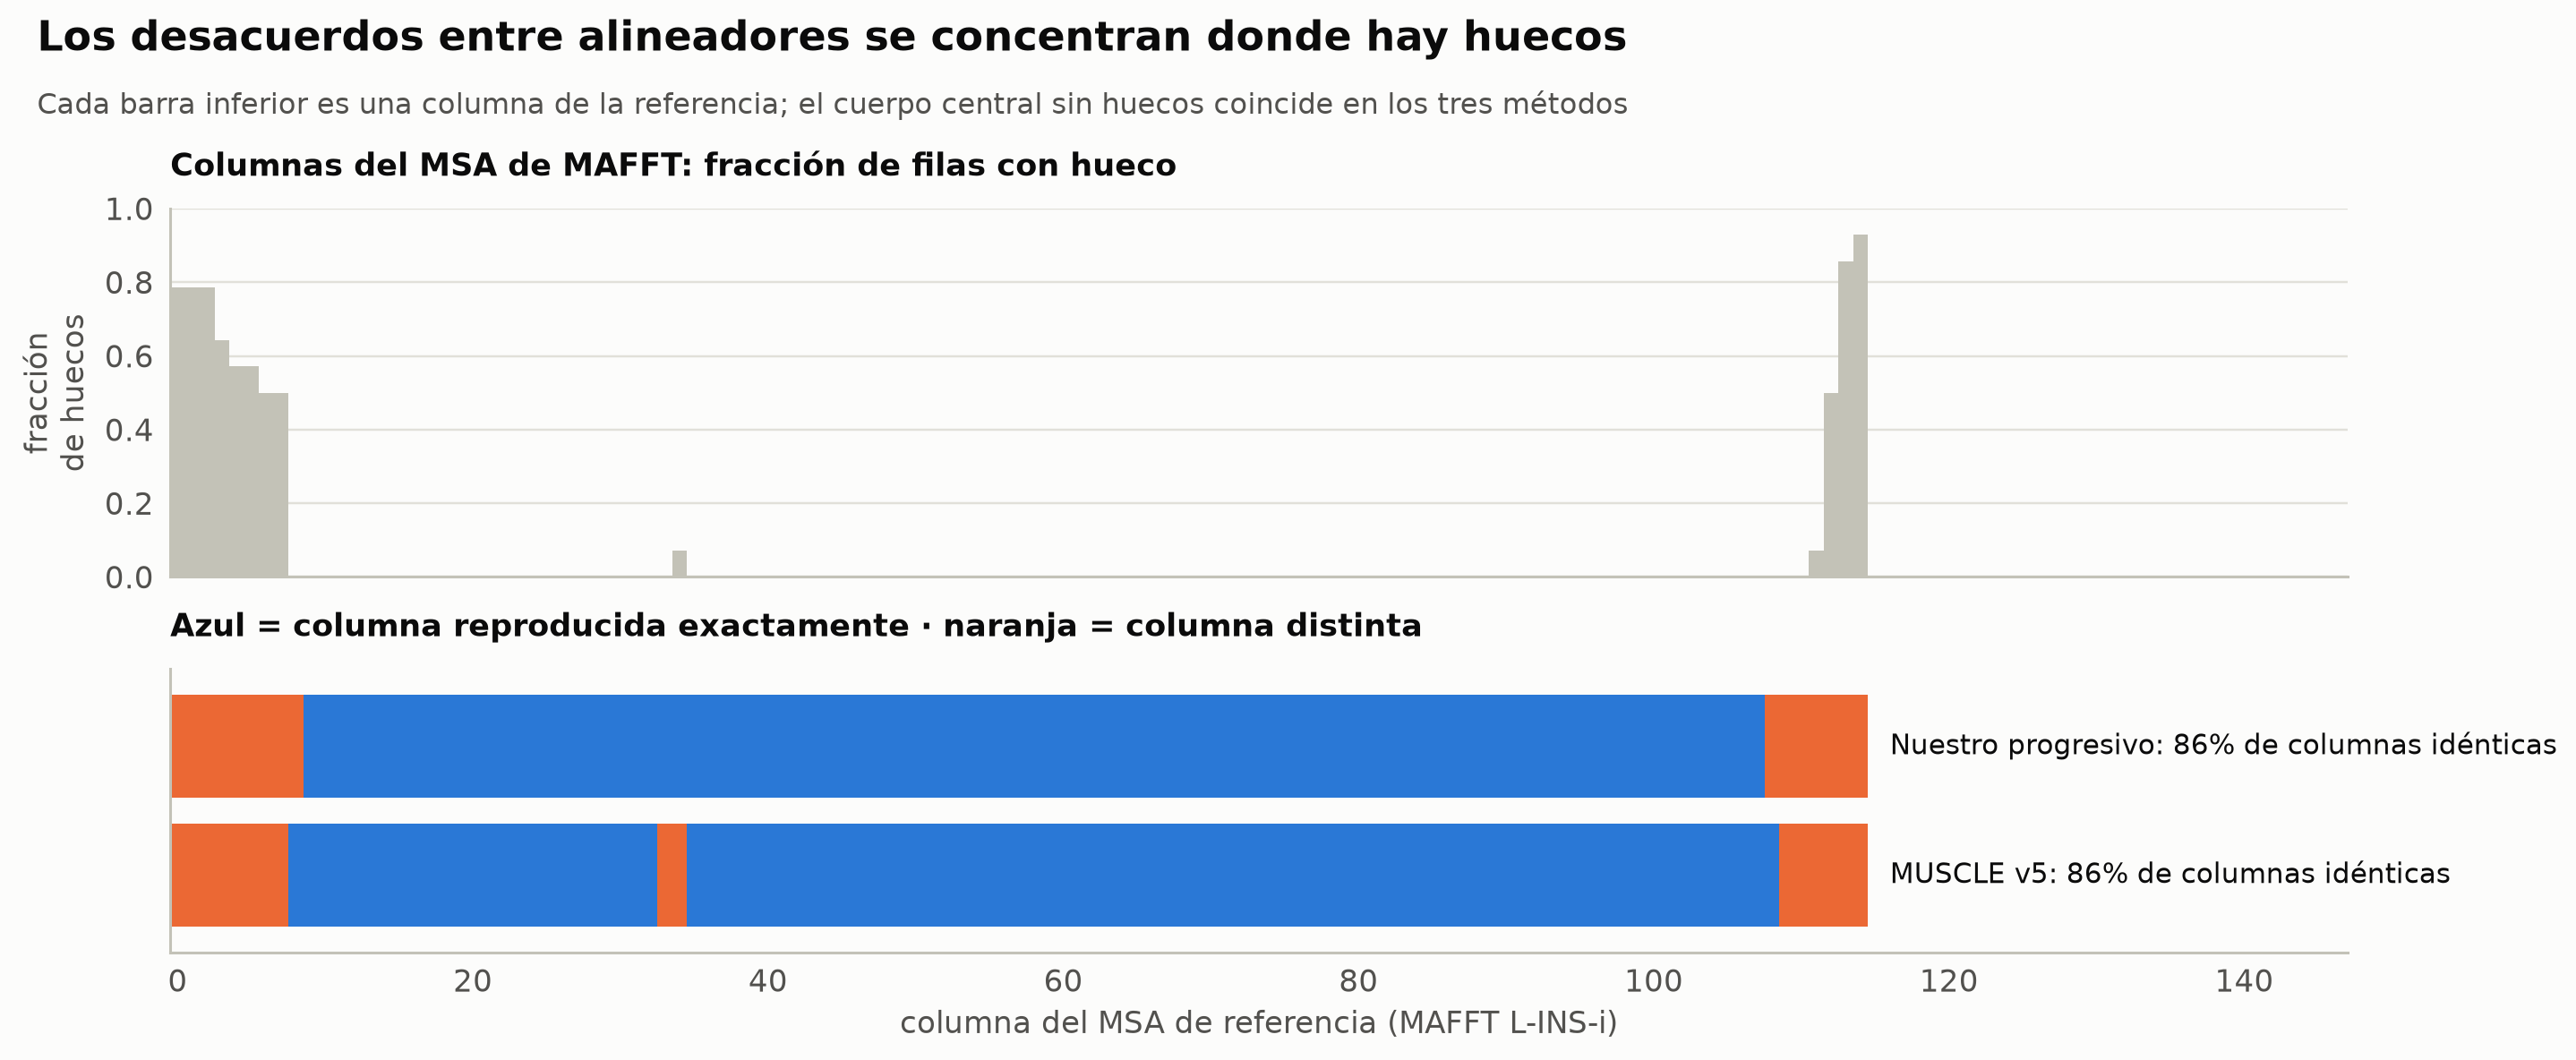

In [17]:
ref_cols = residue_columns(msa_mafft)
agree = {name: [c in set(residue_columns(m)) for c in ref_cols] for name, m in
         [("Nuestro progresivo", msa), ("MUSCLE v5", msa_muscle)]}
gap_frac = np.array([sum(r[c] == "-" for r in msa_mafft) / len(msa_mafft) for c in range(len(msa_mafft[0]))])

fig, (ax_g, ax_a) = plt.subplots(2, 1, figsize=(13, 4.6), height_ratios=[1.3, 1], sharex=True)
ax_g.bar(np.arange(len(gap_frac)), gap_frac, width=1.0, color=ec.BASELINE)
ax_g.set_ylabel("fracción\nde huecos"); ax_g.set_ylim(0, 1)
ax_g.set_title("Columnas del MSA de MAFFT: fracción de filas con hueco", loc="left", fontsize=11.5)
for y, (name, ok) in enumerate(agree.items()):
    ok = np.array(ok)
    ax_a.bar(np.where(ok)[0], 0.8, bottom=y - 0.4, width=1.0, color=ec.BLUE)
    ax_a.bar(np.where(~ok)[0], 0.8, bottom=y - 0.4, width=1.0, color=ec.ORANGE)
    ax_a.text(len(ok) + 1, y, f"{name}: {ok.mean():.0%} de columnas idénticas", va="center", fontsize=10)
ax_a.set_yticks([]); ax_a.set_ylim(1.6, -0.6); ax_a.grid(False)
ax_a.set_xlim(-0.5, len(gap_frac) + 32)
ax_a.set_xlabel("columna del MSA de referencia (MAFFT L-INS-i)")
ax_a.set_title("Azul = columna reproducida exactamente · naranja = columna distinta", loc="left", fontsize=11.5)
ec.fig_title(fig, "Los desacuerdos entre alineadores se concentran donde hay huecos",
             "Cada barra inferior es una columna de la referencia; el cuerpo central sin huecos coincide en los tres métodos")
plt.show()

> 🔎 **Qué observamos.** Los tres métodos están de acuerdo en el **núcleo** de la proteína, la región sin huecos
> que contiene el sitio de unión al hemo. Las diferencias aparecen en los extremos N y C terminales, justo donde hay
> inserciones y deleciones: ahí la colocación de los huecos es **ambigua** (varios alineamientos casi igual de
> buenos) y cada programa desempata a su manera. Nuestro alineador, con huecos lineales (cada posición de hueco cuesta
> lo mismo), tiende además a **fragmentar** los huecos en varios pedazos; los programas reales usan huecos afines,
> que prefieren un hueco largo a varios cortos.

### ¿El progresivo encuentra el óptimo?

Con tres fragmentos cortos podemos comparar contra el óptimo exacto del cubo de la sección 3.

In [18]:
frag_list = list(frag.values())
D3 = distance_matrix(frag_list)
Z3, _ = upgma(D3)
prog3 = progressive_msa(frag_list, Z3)
print("Progresivo:")
for nm, r in zip(frag, prog3): print(f"  {nm:12s} {r}")
print(f"  puntaje SP = {sp_score(prog3):.0f}")
print("Exacto (cubo):")
for nm, r in zip(frag, rows3): print(f"  {nm:12s} {r}")
print(f"  puntaje SP = {best3:.0f}")
gap_to_opt = best3 - sp_score(prog3)
print("\nEl progresivo " + ("alcanza el óptimo" if gap_to_opt == 0 else f"queda {gap_to_opt:.0f} puntos por debajo del óptimo"))

Progresivo:
  Humano       M-G-D-V---E-K-GKKIFIMKCSQCH
  Levadura     MTEFK-A--GSAKKGATLFKTRCLQCH
  Arabidopsis  MASFDEAPPGNAKAGEKIFRTKCAQCH
  puntaje SP = 69
Exacto (cubo):
  Humano       M--------GDVEKGKKIFIMKCSQCH
  Levadura     MTEF-KA--GSAKKGATLFKTRCLQCH
  Arabidopsis  MASFDEAPPGNAKAGEKIFRTKCAQCH
  puntaje SP = 77

El progresivo queda 8 puntos por debajo del óptimo


> 🔎 **Qué observamos.** El progresivo nunca puede superar al óptimo exacto (el cubo examina **todos** los
> alineamientos); en el mejor caso lo iguala. Aquí queda por debajo y se nota por qué: la primera fusión fijó
> decisiones que ya no pudieron corregirse al llegar la tercera secuencia, y los huecos del humano terminaron
> **repartidos en muchos pedazos**, mientras que el óptimo los agrupa en un solo bloque al principio (una sola
> inserción N-terminal, que es la explicación biológica más sencilla). Con decenas de secuencias divergentes estos
> errores tempranos se acumulan.

✅ **Compruebe su comprensión.** ¿Por qué el refinamiento iterativo de MAFFT y MUSCLE puede **mejorar** el puntaje
de un MSA progresivo, pero nunca **garantiza** llegar al óptimo?

## 11. Leer un MSA: mosaico químico, conservación y consenso

Un MSA de 14 × 115 caracteres es ilegible como texto. Programas como **Jalview** lo muestran como un **mosaico**:
cada residuo es una celda coloreada según su **clase química**. Así, una columna de un solo color indica que la
química se conservó aunque el aminoácido haya cambiado (por ejemplo, K ↔ R, ambos positivos).

| Clase | Aminoácidos | Por qué importa |
|---|---|---|
| hidrofóbico | A V L I M | núcleo de la proteína, lejos del agua |
| aromático | F W Y | anillos planos: apilamiento, núcleo |
| positivo | K R H | cargas +; en el citocromo *c* forman el parche que "atraca" en sus socios redox |
| negativo | D E | cargas − |
| polar | S T N Q | puentes de hidrógeno en la superficie |
| glicina | G | flexibilidad: giros cerrados |
| prolina | P | rigidez: rompe hélices |
| cisteína | C | puentes disulfuro o, aquí, **enlace covalente con el hemo** |

Usaremos el MSA de MAFFT (el más cuidadoso de los tres) y ordenaremos las filas según el árbol guía.

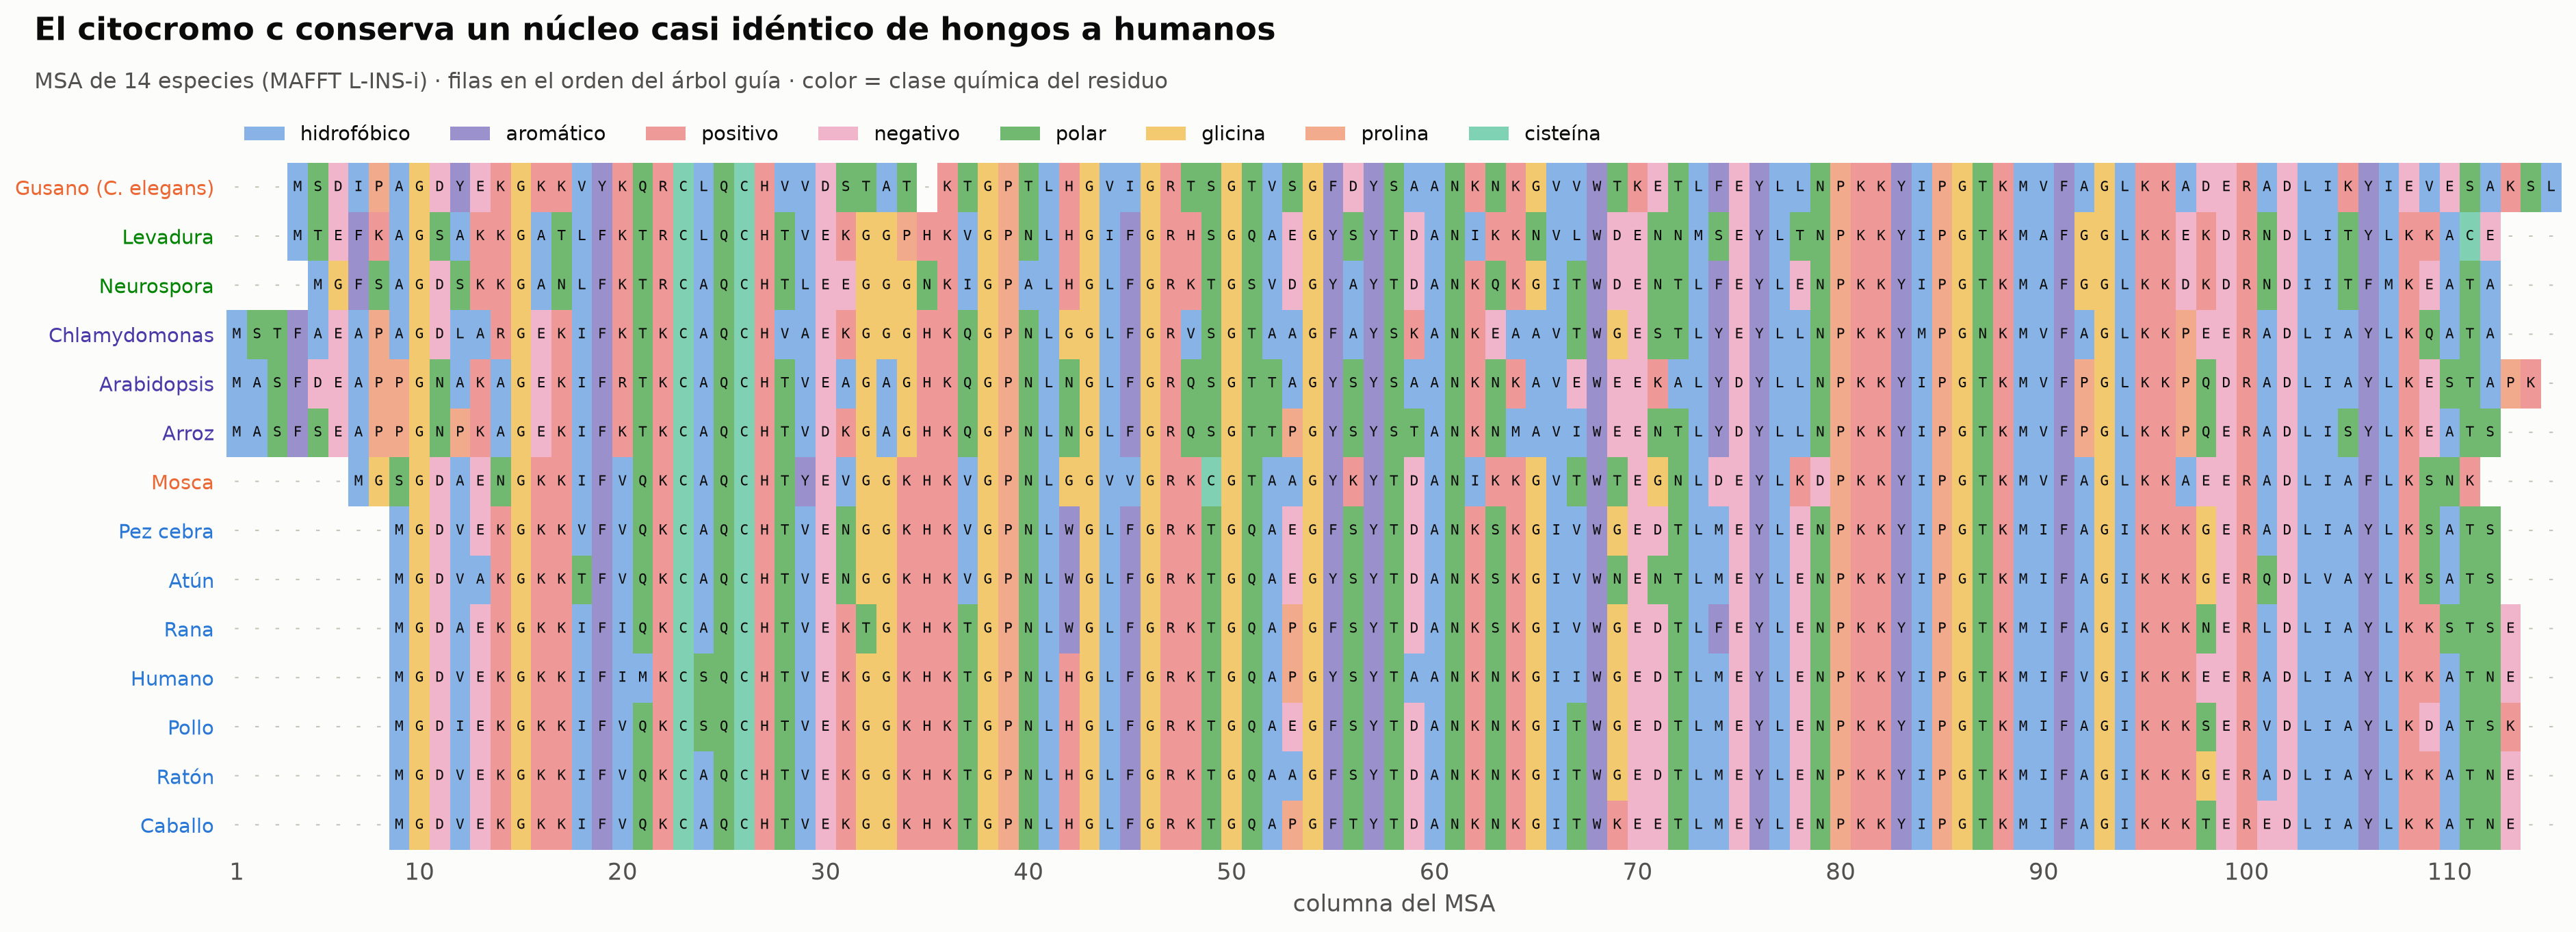

In [19]:
best_msa = msa_mafft
L_best = len(best_msa[0])

def draw_msa(ax, rows, labels, start=0, end=None, fs=6.8, label_colors=None):
    """Mosaico estilo Jalview: celda coloreada por clase química y la letra encima."""
    end = end or len(rows[0])
    img = np.ones((len(rows), end - start, 3)) * np.array(to_rgb(ec.SURFACE))
    for y, r in enumerate(rows):
        for x, ch in enumerate(r[start:end]):
            if ch != "-":
                img[y, x] = soft(CLASS_COLOR[AA_CLASS.get(ch, "polar")], 0.55)
    ax.imshow(img, aspect="auto", interpolation="nearest",
              extent=(start + 0.5, end + 0.5, len(rows) - 0.5, -0.5))
    for y, r in enumerate(rows):
        for x, ch in enumerate(r[start:end]):
            ax.text(start + x + 1, y, ch, ha="center", va="center", fontsize=fs,
                    color=ec.INK if ch != "-" else ec.BASELINE, family="DejaVu Sans Mono")
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels(labels, fontsize=9.5)
    if label_colors:
        for t in ax.get_yticklabels():
            t.set_color(label_colors[t.get_text()])
    ax.grid(False)
    for sp in ax.spines.values(): sp.set_visible(False)

rows_sorted = [best_msa[i] for i in leaf_order]
labels_sorted = [names[i] for i in leaf_order]
fig, ax = plt.subplots(figsize=(17, 5.4))
draw_msa(ax, rows_sorted, labels_sorted, label_colors=name_colors)
ax.set_xticks([1] + list(range(10, L_best + 1, 10)))
ax.set_xlabel("columna del MSA")
handles = [Rectangle((0, 0), 1, 1, color=soft(c, 0.55)) for c in CLASS_COLOR.values()]
ax.legend(handles, CLASSES, ncol=8, loc="lower left", bbox_to_anchor=(0, 1.0), frameon=False, fontsize=9.5)
ax.set_title("")
ec.fig_title(fig, "El citocromo c conserva un núcleo casi idéntico de hongos a humanos",
             "MSA de 14 especies (MAFFT L-INS-i) · filas en el orden del árbol guía · color = clase química del residuo")
plt.show()

> 🔎 **Qué observamos.** Hay bloques de columnas de **un solo color y una sola letra** (por ejemplo `CAQCH`,
> `GPNL`, `NPKKYIPGTKM`) y regiones más "coloridas" donde se toleran sustituciones. Las extensiones N-terminales
> sólo existen en hongos, gusano y plantas. A simple vista ya se ve la estructura de la proteína que no
> muestra ningún alineamiento por pares.

### Conservación: entropía de Shannon por columna

Para convertir "esta columna se ve muy conservada" en un número usamos la **entropía de Shannon** (Lección 1.3):
mide cuánta incertidumbre hay sobre qué residuo aparecerá en esa columna.

$$
H(c) \;=\; -\sum_{a} p_{a,c}\,\log_2 p_{a,c},
\qquad 0 \le H(c) \le \log_2 20 \approx 4.32 \text{ bits},
\qquad \text{identidad}(c) = \max_a \frac{n_{a,c}}{k}
$$

| Símbolo | Significado |
|---|---|
| $p_{a,c}$ | fracción de los **residuos** de la columna $c$ que son el aminoácido $a$ (los huecos se excluyen) |
| $H(c)$ | entropía: 0 = columna idéntica; 4.32 = los 20 aminoácidos igual de frecuentes |
| $n_{a,c}$ | número de secuencias con el aminoácido $a$ en la columna $c$ |
| identidad$(c)$ | fracción de las $k$ secuencias que llevan el residuo más común (aquí un hueco sí baja la identidad) |

**Ejemplo a mano.** Columna con 10 K y 4 R (sin huecos): $p_K = 10/14 = 0.714$, $p_R = 0.286$.
$H = -(0.714 \log_2 0.714 + 0.286 \log_2 0.286) = -(0.714 \times (-0.486) + 0.286 \times (-1.807)) = 0.86$ bits.
Identidad = 0.714. Una columna con los 14 residuos iguales tiene $H = 0$ e identidad 1.

**Advertencia:** con sólo 14 secuencias la entropía máxima alcanzable es $\log_2 14 \approx 3.8$ bits, y con
pocas secuencias casi idénticas (los 7 vertebrados) la entropía **subestima** la variabilidad real. Por eso los
métodos serios ponderan las secuencias (como hace CLUSTAL W).

La **secuencia consenso** escribe, para cada columna, el residuo más común: en mayúscula si está en **todas** las
secuencias, en minúscula si está en al menos la mitad, y `.` si ninguno llega a la mitad.

In [20]:
def column_stats(rows):
    k = len(rows); out = []
    for c in range(len(rows[0])):
        col = [r[c] for r in rows]
        res = [x for x in col if x != "-"]
        counts = pd.Series(res).value_counts()
        p = counts.values / counts.values.sum()
        top, n_top = counts.index[0], counts.values[0]
        cons = top if n_top == k else (top.lower() if n_top >= k / 2 else ".")
        out.append(dict(columna=c + 1, entropia=float(-(p * np.log2(p)).sum()) + 0.0, identidad=n_top / k,
                        huecos=col.count("-") / k, consenso=cons, residuo_top=top))
    return pd.DataFrame(out)

stats = column_stats(best_msa)
consensus = "".join(stats.consenso)
print("Consenso:", consensus)
print(f"Columnas 100 % idénticas: {(stats.identidad == 1).sum()} de {len(stats)}")

# Posiciones clave en numeración de la proteína humana madura (sin la metionina inicial)
human = best_msa[names.index("Humano")]
human_pos = np.cumsum([ch != "-" for ch in human])           # posición UniProt de cada columna
key_sites = {"C14": 15, "C17": 18, "H18": 19, "M80": 81}      # posición madura → posición UniProt (+1 por la Met)
key_cols = {}
for label, uniprot_pos in key_sites.items():
    col = int(np.where((human_pos == uniprot_pos) & (np.array(list(human)) != "-"))[0][0])
    key_cols[label] = col
    print(f"{label}: columna {col + 1}, residuo humano {human[col]}, identidad {stats.identidad[col]:.0%}")

Consenso: ........mGd.ekGkkif.qkCaQCHtvekggkhK.GPnLhGlfGRktGqa.GysYtdANknkgi.W.e.tl.eYLenPKKYiPGtKMiFaGiKKk.eRaDliaylk.at....
Columnas 100 % idénticas: 35 de 115
C14: columna 23, residuo humano C, identidad 100%
C17: columna 26, residuo humano C, identidad 100%
H18: columna 27, residuo humano H, identidad 100%
M80: columna 89, residuo humano M, identidad 100%


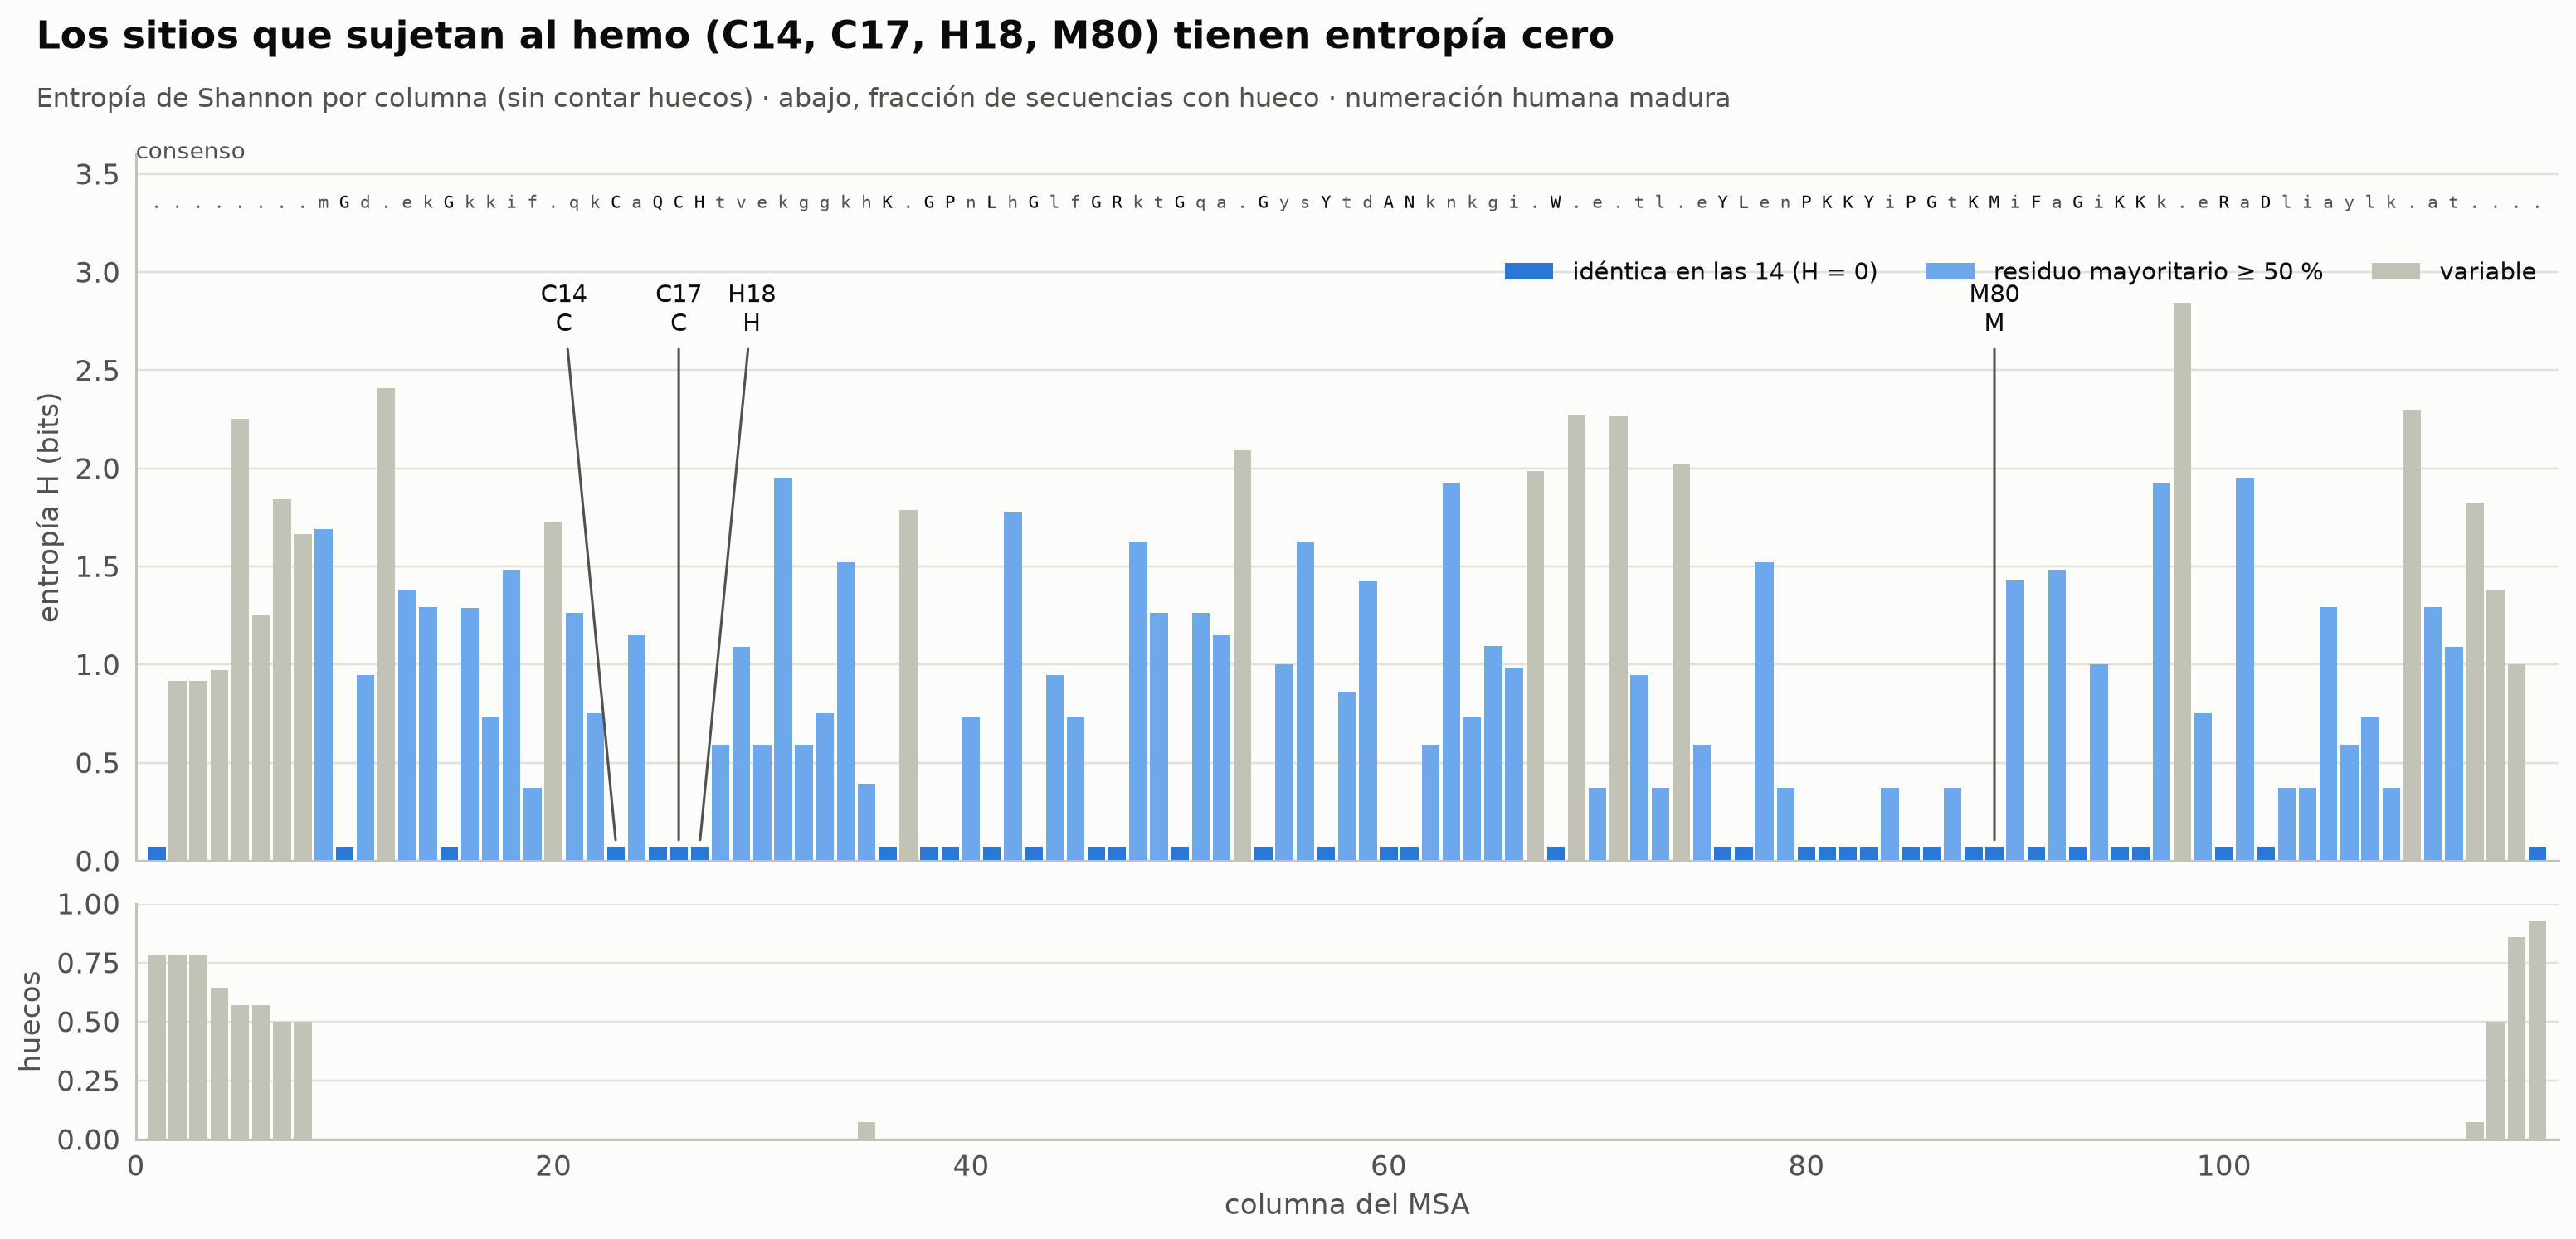

In [21]:
fig, (ax_h, ax_g) = plt.subplots(2, 1, figsize=(14, 6), height_ratios=[3, 1], sharex=True)
x = stats.columna.values
colors = [ec.BLUE if i == 1 else (ec.SEQ_BLUE[4] if i >= 0.5 else ec.BASELINE) for i in stats.identidad]
ax_h.bar(x, stats.entropia, width=0.85, color=colors)
ax_h.set_ylabel("entropía H (bits)")
ax_h.set_ylim(0, 3.6)
zero = stats.entropia == 0                                      # H = 0 no tiene altura: la marcamos con un tope
ax_h.bar(x[zero], 0.07, width=0.85, color=ec.BLUE)
for (label, col), dx in zip(key_cols.items(), [-2.5, 0, 2.5, 0]):
    ax_h.annotate(f"{label}\n{stats.residuo_top[col]}", (col + 1, 0.08), xytext=(col + 1 + dx, 2.7),
                  ha="center", fontsize=9.5, color=ec.INK,
                  arrowprops=dict(arrowstyle="-", color=ec.INK_2, lw=1))
for i, ch in enumerate(consensus):
    ax_h.text(i + 1, 3.35, ch, ha="center", va="center", fontsize=7, family="DejaVu Sans Mono",
              color=ec.INK if ch.isupper() else ec.INK_2)
ax_h.text(0, 3.55, "consenso", fontsize=9, color=ec.INK_2, va="bottom")
handles = [Rectangle((0, 0), 1, 1, color=c) for c in (ec.BLUE, ec.SEQ_BLUE[4], ec.BASELINE)]
ax_h.legend(handles, ["idéntica en las 14 (H = 0)", "residuo mayoritario ≥ 50 %", "variable"], ncol=3,
            loc="upper right", bbox_to_anchor=(1, 0.88), fontsize=9.5)
ax_g.bar(x, stats.huecos, width=0.85, color=ec.BASELINE)
ax_g.set_ylabel("huecos"); ax_g.set_ylim(0, 1)
ax_g.set_xlabel("columna del MSA")
ax_g.set_xlim(0, len(x) + 1)
ec.fig_title(fig, "Los sitios que sujetan al hemo (C14, C17, H18, M80) tienen entropía cero",
             "Entropía de Shannon por columna (sin contar huecos) · abajo, fracción de secuencias con hueco · numeración humana madura")
plt.show()

> 🔎 **Qué observamos.** Muchas columnas tienen entropía **cero**. Entre ellas están exactamente los residuos que la
> bioquímica señala como esenciales: las cisteínas 14 y 17 (unidas covalentemente al hemo) y los dos ligandos del
> hierro, la histidina 18 y la metionina 80. Sin saber nada de estructura, **la conservación en un MSA señala la
> función**. Las columnas con muchos huecos (extremos) son también las más variables.

### 🔬 Visor interactivo del MSA

Pase el cursor por cualquier celda: verá la especie, el residuo, su posición en la secuencia original, la columna y
la conservación de esa columna. La vista inicial muestra las primeras 60 columnas: arrastre el gráfico hacia la
izquierda para recorrer el resto, o use la lupa de la barra de herramientas para hacer zoom; doble clic para volver.

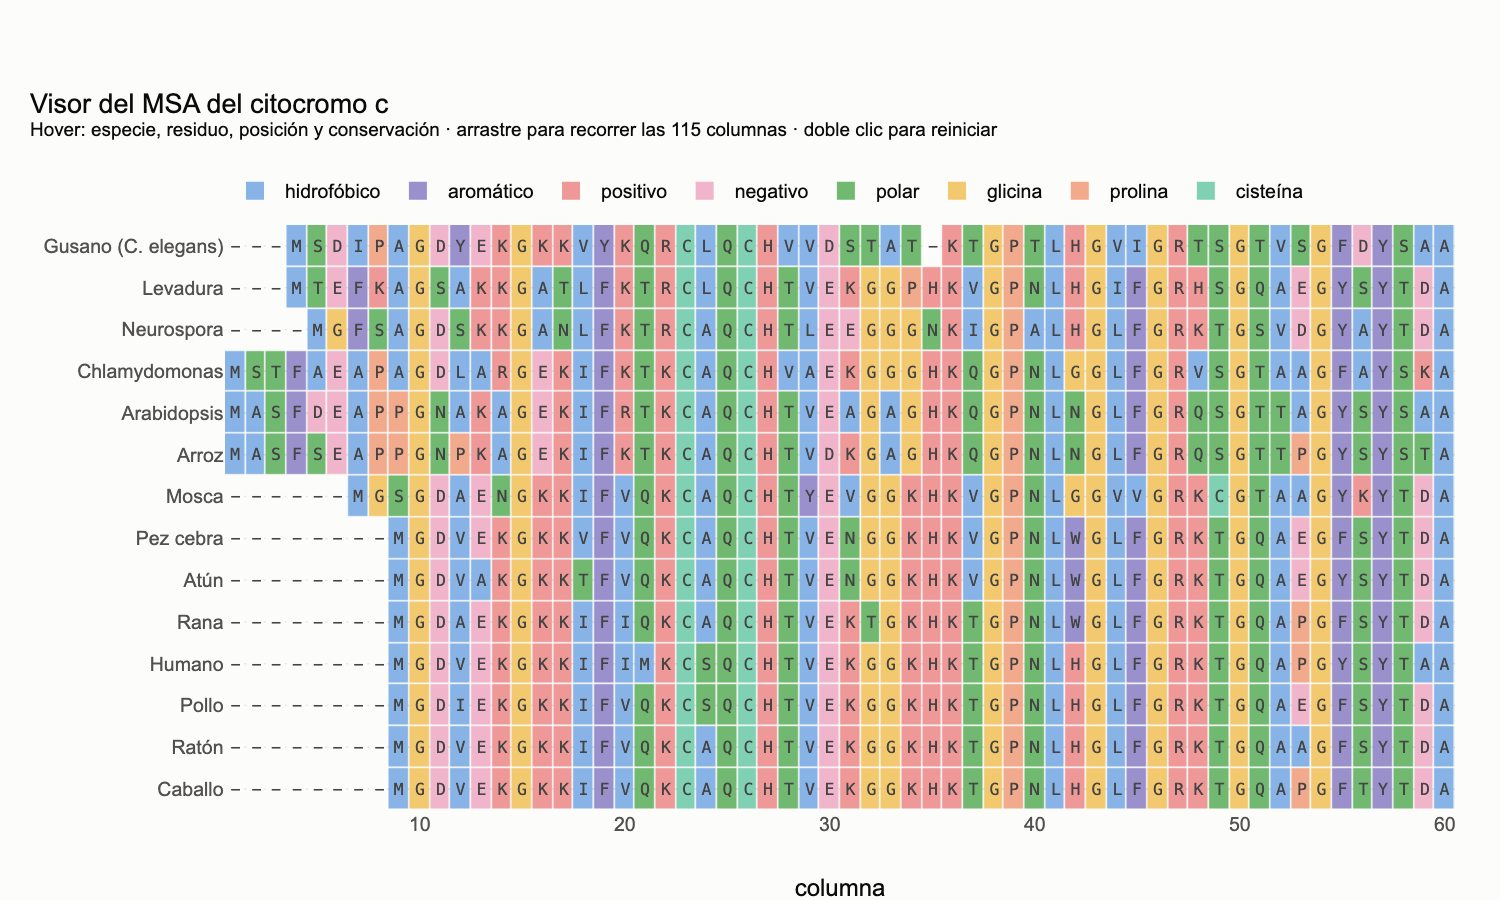

In [22]:
class_index = {c: i for i, c in enumerate(CLASSES)}
k_rows, L = len(rows_sorted), len(rows_sorted[0])
z = np.full((k_rows, L), len(CLASSES), dtype=float)            # último índice = hueco
hover = []
for y, r in enumerate(rows_sorted):
    pos, row_h = 0, []
    for c, ch in enumerate(r):
        st = stats.iloc[c]
        if ch != "-":
            pos += 1
            z[y, c] = class_index[AA_CLASS[ch]]
            what = f"<b>{ch}</b> ({AA_CLASS[ch]}) · residuo {pos} de la secuencia"
        else:
            what = "<b>hueco</b>"
        row_h.append(f"{labels_sorted[y]}<br>{what}<br>columna {c + 1} · consenso <b>{st.consenso}</b>"
                     f"<br>entropía {st.entropia:.2f} bits · identidad {st.identidad:.0%} · huecos {st.huecos:.0%}")
    hover.append(row_h)

n_cls = len(CLASSES) + 1
palette = [f"rgb{tuple(int(255 * v) for v in soft(CLASS_COLOR[c], 0.55))}" for c in CLASSES] + [ec.SURFACE]
colorscale = []
for i, col in enumerate(palette):
    colorscale += [[i / n_cls, col], [(i + 1) / n_cls, col]]

fig = go.Figure(go.Heatmap(z=z, x=np.arange(1, L + 1), y=labels_sorted, text=[list(r) for r in rows_sorted],
                           texttemplate="%{text}", textfont=dict(size=11, family="DejaVu Sans Mono, monospace"),
                           customdata=hover, hovertemplate="%{customdata}<extra></extra>",
                           colorscale=colorscale, zmin=0, zmax=n_cls, showscale=False, xgap=1, ygap=1))
for c, col in zip(CLASSES, palette[:-1]):                    # leyenda de clases químicas
    fig.add_trace(go.Scatter(x=[None], y=[None], mode="markers", name=c,
                             marker=dict(symbol="square", size=12, color=col)))
fig.update_layout(title=dict(text="Visor del MSA del citocromo c<br><sup>Hover: especie, residuo, posición y "
                                  "conservación · arrastre para recorrer las 115 columnas · doble clic para reiniciar</sup>"),
                  height=600, margin=dict(t=150, l=150, r=30, b=60),
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0),
                  dragmode="pan", xaxis=dict(range=[0.5, 60.5], title="columna"),
                  yaxis=dict(autorange="reversed"))
fig.show()

### Identidad por pares, ordenada por el árbol

Del MSA también se obtiene la **identidad** de cada par de secuencias (fracción de columnas idénticas entre las que
ninguna de las dos tiene hueco). Ordenando filas y columnas como el árbol guía, los grupos taxonómicos aparecen como
bloques.

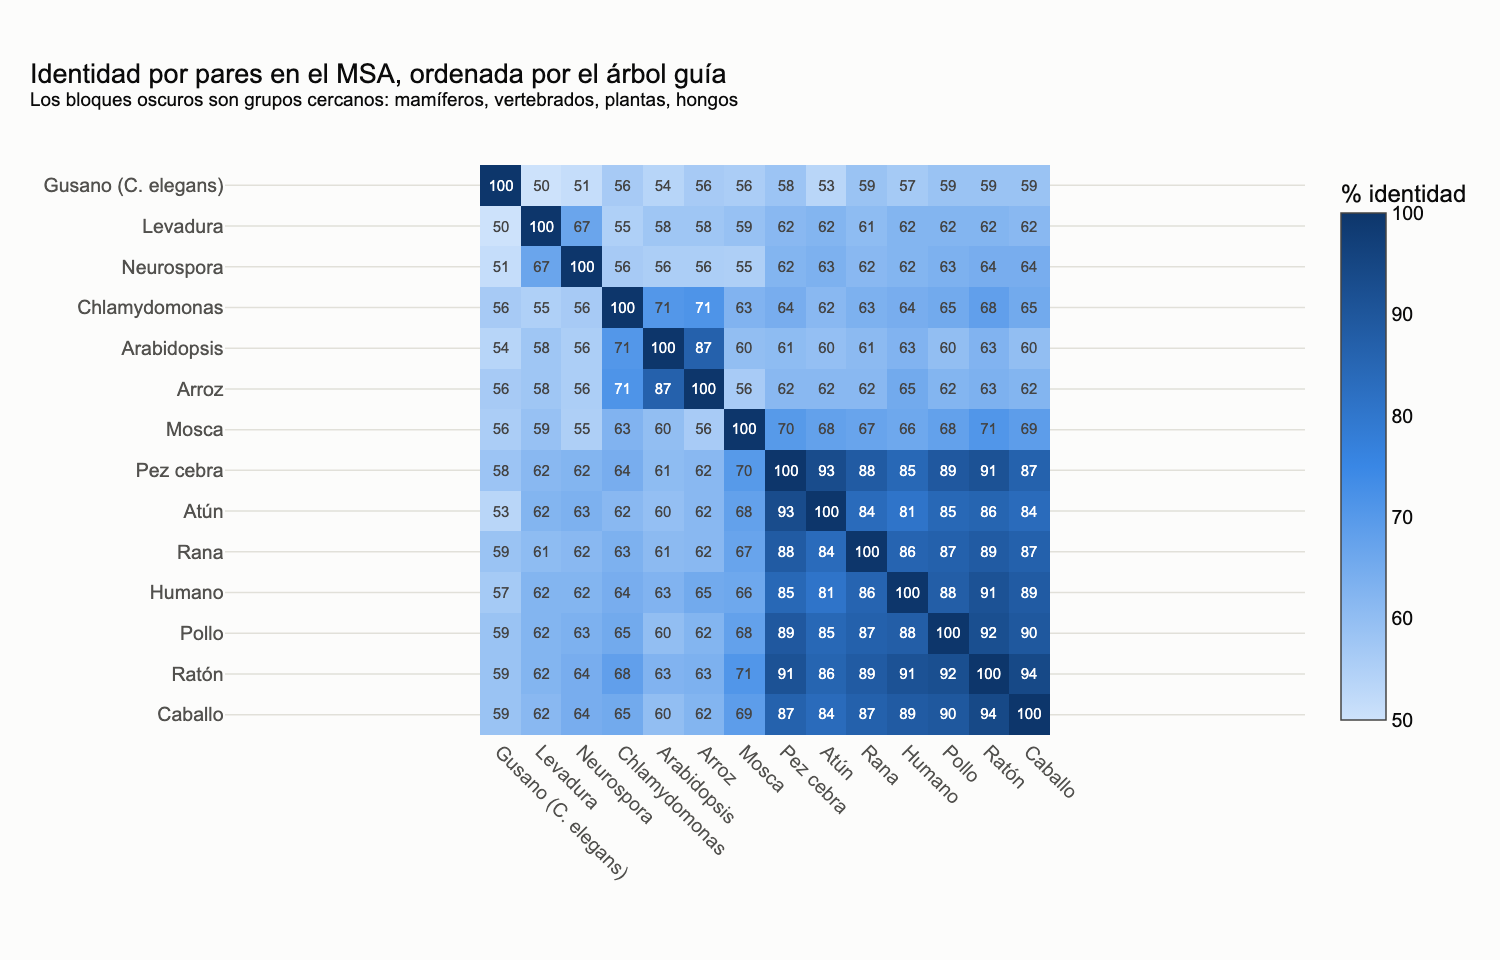

In [23]:
def pairwise_identity(rows):
    k = len(rows); I = np.eye(k); N = np.zeros((k, k), dtype=int)
    for i, j in itertools.combinations(range(k), 2):
        cols = [(x, y) for x, y in zip(rows[i], rows[j]) if x != "-" and y != "-"]
        I[i, j] = I[j, i] = sum(x == y for x, y in cols) / len(cols); N[i, j] = N[j, i] = len(cols)
    return I, N

I_msa, N_msa = pairwise_identity(rows_sorted)
hover_i = [[f"{labels_sorted[i]} vs {labels_sorted[j]}<br>identidad <b>{I_msa[i, j]:.0%}</b>"
            f"<br>{N_msa[i, j]} columnas comparadas (sin huecos)" + (f"<br>grupos: {GROUP[labels_sorted[i]]} · "
            f"{GROUP[labels_sorted[j]]}" if i != j else "") for j in range(k_rows)] for i in range(k_rows)]
fig = go.Figure(go.Heatmap(z=I_msa * 100, x=labels_sorted, y=labels_sorted, customdata=hover_i,
                           hovertemplate="%{customdata}<extra></extra>", colorscale=[[0, ec.SEQ_BLUE[0]],
                           [0.5, ec.SEQ_BLUE[6]], [1, ec.SEQ_BLUE[-1]]], zmin=50, zmax=100,
                           colorbar=dict(title="% identidad"),
                           text=np.round(I_msa * 100).astype(int), texttemplate="%{text}",
                           textfont=dict(size=10)))
fig.update_layout(title=dict(text="Identidad por pares en el MSA, ordenada por el árbol guía<br><sup>Los bloques "
                                  "oscuros son grupos cercanos: mamíferos, vertebrados, plantas, hongos</sup>"),
                  height=640, width=760, margin=dict(t=110, l=150, b=150))
fig.update_yaxes(autorange="reversed", scaleanchor="x")
fig.update_xaxes(tickangle=45)
fig.show()

> 🔎 **Qué observamos.** Los mamíferos comparten ≈ 90 % de identidad; los vertebrados, > 80 %. Entre reinos la
> identidad baja a ≈ 50–65 %, muy por encima del 20–25 % que esperaríamos entre proteínas no relacionadas
> (la "zona crepuscular" de la Lección 3.4). El orden del árbol convierte la matriz en bloques: es otra forma de
> ver el árbol guía.

## 12. 🧪 ¿Qué tan bueno es un MSA? El costo de los huecos en datos simulados

Con proteínas reales nunca sabemos cuál es el alineamiento **verdadero**. Con una simulación sí: inventamos una
secuencia ancestral, la hacemos evolucionar a lo largo de un árbol con **sustituciones** (sorteadas con las
probabilidades implícitas en BLOSUM62) e **inserciones/deleciones**, y llevamos la cuenta de qué residuo desciende
de cuál. Al final tenemos las secuencias **y** su MSA verdadero, y podemos medir $Q_{\text{SP}}$ y TC sin ambigüedad.

La probabilidad de que el residuo $a$ se sustituya por $b$ sale de la definición de BLOSUM62 (Lección 3.3):
$s(a,b) = 2\log_2\!\big(q_{ab} / (p_a p_b)\big)$, así que

$$
P(b \mid a) \;\propto\; p_b \; 2^{\,s(a,b)/2}, \qquad b \neq a
$$

| Símbolo | Significado |
|---|---|
| $p_b$ | frecuencia de fondo del aminoácido $b$ (la tomamos del citocromo *c*) |
| $s(a,b)$ | puntaje BLOSUM62 en medios bits |
| $q_{ab}$ | frecuencia con que $a$ y $b$ aparecen alineados en proteínas emparentadas |

Así las sustituciones "se parecen" a las reales: K se convierte más a menudo en R que en W.

🤔 **Antes de ejecutar, prediga:** si el hueco es **muy barato** ($g$ cercano a 0), ¿qué hará el alineador? ¿Y si
es **muy caro**? ¿Existirá un valor intermedio óptimo?

In [24]:
bg = pd.Series(list("".join(seqs))).value_counts(normalize=True).reindex(list(AA)).fillna(0.001)
bg = (bg / bg.sum()).values
SUBST = np.array([[0 if a == b else bg[j] * 2 ** (BLOSUM62[a, b] / 2) for j, b in enumerate(AA)] for a in AA])
SUBST = SUBST / SUBST.sum(axis=1, keepdims=True)
AA_IDX = {a: i for i, a in enumerate(AA)}

def evolve(seq, t, rng, indel_rate=0.06):
    """seq = lista de (id, aa). Sustituciones con prob 1-e^{-t} por sitio e indels con longitud geométrica."""
    out = [(i, rng.choice(list(AA), p=SUBST[AA_IDX[a]]) if rng.random() < 1 - np.exp(-t) else a) for i, a in seq]
    for _ in range(rng.poisson(indel_rate * t * len(out))):
        size = min(rng.geometric(0.45), 6); pos = rng.integers(0, len(out) + 1)
        if rng.random() < 0.5 and len(out) > 30:                            # deleción
            del out[pos:pos + size]
        else:                                                             # inserción con identificadores nuevos
            left = out[pos - 1][0] if pos > 0 else out[0][0] - 1
            right = out[pos][0] if pos < len(out) else out[-1][0] + 1
            new = [(left + (right - left) * (q + 1) / (size + 1), rng.choice(list(AA), p=bg)) for q in range(size)]
            out[pos:pos] = new
    return out

def simulate_family(k=10, length=100, mean_branch=0.10, seed=0):
    """Árbol aleatorio tipo Yule; devuelve las secuencias y su MSA verdadero."""
    rng = np.random.default_rng(seed)
    root = [(float(i), a) for i, a in enumerate(rng.choice(list(AA), size=length, p=bg))]
    leaves = [root]
    while len(leaves) < k:
        parent = leaves.pop(rng.integers(len(leaves)))
        leaves += [evolve(parent, rng.exponential(mean_branch), rng) for _ in range(2)]
    leaves = [evolve(s, rng.exponential(mean_branch), rng) for s in leaves]
    ids = sorted({i for s in leaves for i, _ in s})
    true_msa = []
    for s in leaves:
        d = dict(s)
        true_msa.append("".join(d.get(i, "-") for i in ids))
    return [s.replace("-", "") for s in true_msa], true_msa

sim_seqs, sim_true = simulate_family(seed=1)
I_sim, _ = pairwise_identity(sim_true)
print(f"{len(sim_seqs)} secuencias de {min(map(len, sim_seqs))}–{max(map(len, sim_seqs))} residuos; "
      f"identidad media por pares {I_sim[np.triu_indices(len(sim_seqs), 1)].mean():.0%}")
print("MSA verdadero (primeras 70 columnas):")
for r in sim_true: print("  ", r[:70])

10 secuencias de 97–112 residuos; identidad media por pares 56%
MSA verdadero (primeras 70 columnas):
   LYNYGHSGNAFL-GPG--INGC-EFEINY----MLFYDVLNKPKWALIAKT-KETLLVA-----------
   IYNYYHLGLAGL-GGA--KNNCDWFGSKY----MLD-KMLNKPEALLKEEG-RYTLLWSS------K---
   LYNYGHSGMAGL-GGG--IGGCDGFEIEIYASEMLE-SVKGKPKWLLKAKT-KYALLKNS------E---
   LYNYGHSGLASL-GGA--LNGCDEFEIEY----QLE-DVLNKPKWLTKLKT-KYTLLWNQ------KEKD
   LYNYGPSGLAGL-GGG--INGCDKFEIEL----QEE-DLLNKKAWLLKAKT-KYTALWNQ------L---
   LYNYGHSGLAGL-GGK--IGGCDEFEIEY----QLE-DVLNKPKVLLKLKT-KYTLLWNQ------K---
   IYTTGHLGLGGQ-AGG--INGCDKIPIKY----QLE-SKLLAPEGVNKPKV-KATLTRNAIWAVLLK---
   LYMYGHSGLAGL-GFG--INKCDEFEIEY----QLK-DALNKPKWLLKAKV-KYKLLINQ------K---
   LYNYGH-GLAGM-EGAKATLGCDEFEIEY----TIE-DVLNKAKWLLKLKT-KYTVLWNK------K---
   LNNYGHSG-AGMGGGD--TLGCSEFEIEY----HLA-DVLNKAYALKKLKTK---LLWNQ------K---


In [25]:
gap_grid = [-1, -2, -4, -6, -8, -11, -15, -20]
rows_exp = []
t0 = time.perf_counter()
for seed in range(6):
    s_seqs, s_true = simulate_family(seed=100 + seed)
    Zs, _ = upgma(distance_matrix(s_seqs))
    for g in gap_grid:
        test = progressive_msa(s_seqs, Zs, gap=g)
        rows_exp.append(dict(semilla=seed, g=g, Q_SP=q_sp(test, s_true), TC=tc(test, s_true),
                             columnas=len(test[0]) / len(s_true[0])))
    if HAS_MAFFT:
        SeqIO.write([SeqRecord(Seq(s), id=f"s{i}", description="") for i, s in enumerate(s_seqs)],
                    "sim.fasta", "fasta")
        out = subprocess.run(["mafft", "--quiet", "sim.fasta"], capture_output=True, text=True).stdout
        test = [str(r.seq).upper() for r in SeqIO.parse(io.StringIO(out), "fasta")]
        rows_exp.append(dict(semilla=seed, g="MAFFT", Q_SP=q_sp(test, s_true), TC=tc(test, s_true),
                             columnas=len(test[0]) / len(s_true[0])))
bench = pd.DataFrame(rows_exp)
print(f"{len(bench)} alineamientos evaluados en {time.perf_counter() - t0:.1f} s")
summary = bench[bench.g != "MAFFT"].groupby("g")[["Q_SP", "TC", "columnas"]].mean().sort_index(ascending=False)
summary.style.format("{:.3f}")

48 alineamientos evaluados en 2.0 s


,Q_SP,TC,columnas
g,,,
-1,0.720,0.297,1.417
-2,0.846,0.497,1.137
-4,0.910,0.641,1.042
-6,0.944,0.731,1.000
-8,0.936,0.731,0.994
-11,0.928,0.722,0.989
-15,0.913,0.681,0.988
-20,0.883,0.617,0.983


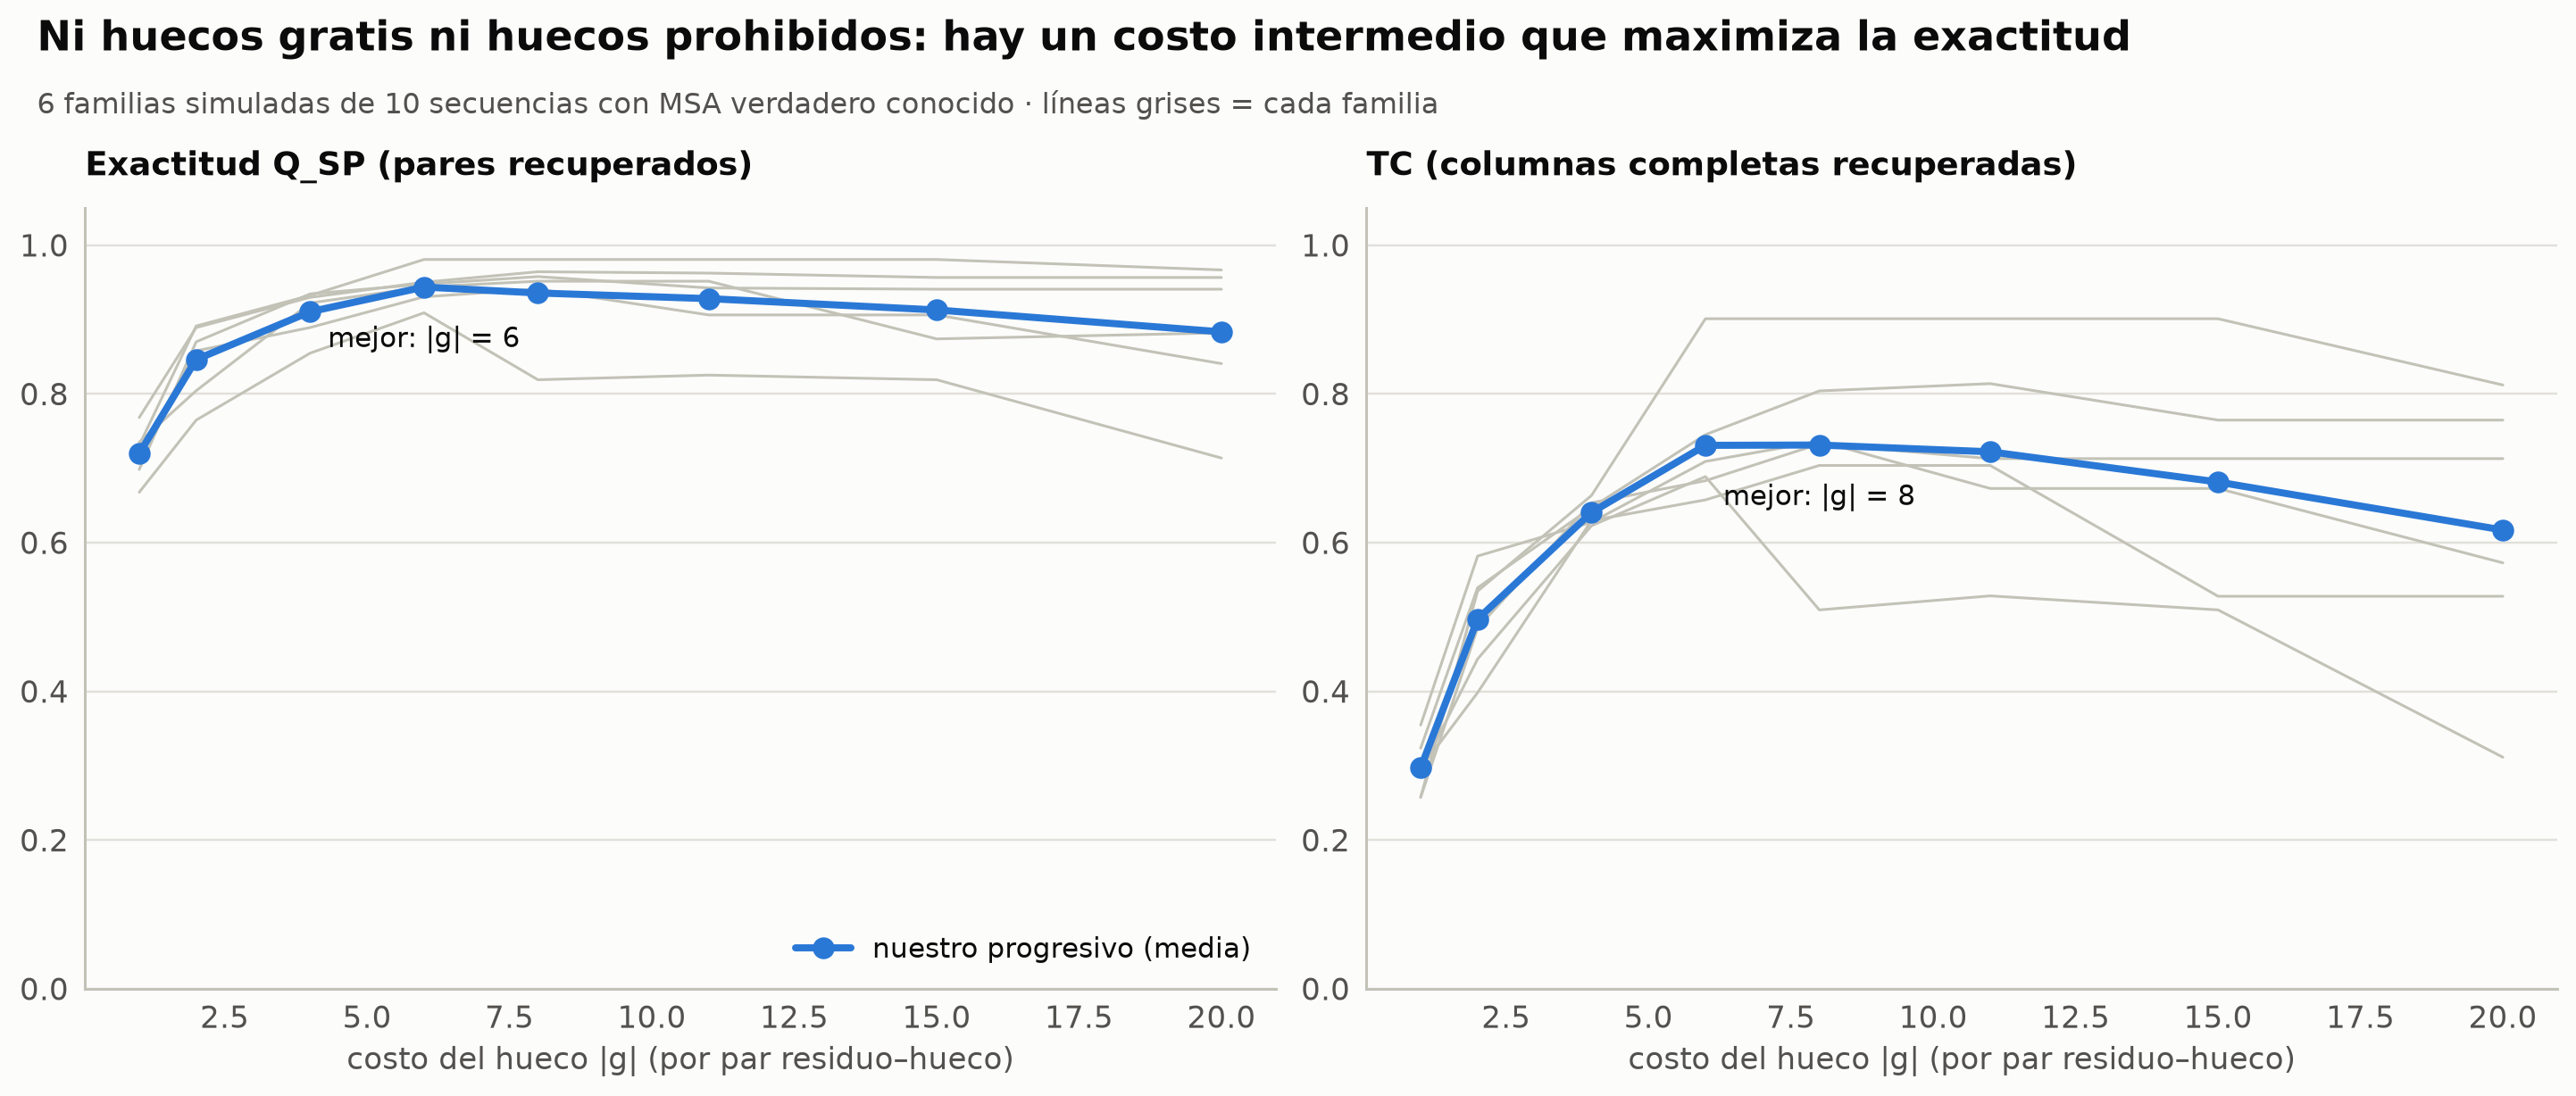

In [26]:
prog = bench[bench.g != "MAFFT"].copy(); prog["costo"] = -prog.g.astype(float)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
for ax, metric, name in [(axes[0], "Q_SP", "Exactitud Q_SP (pares recuperados)"),
                         (axes[1], "TC", "TC (columnas completas recuperadas)")]:
    for seed, grp in prog.groupby("semilla"):
        ax.plot(grp.costo, grp[metric], color=ec.BASELINE, lw=1)
    mean = prog.groupby("costo")[metric].mean()
    ax.plot(mean.index, mean.values, "o-", color=ec.BLUE, lw=2.6, label="nuestro progresivo (media)")
    best_g = mean.idxmax()
    ax.annotate(f"mejor: |g| = {best_g:g}", (best_g, mean.max()), xytext=(0, -22), textcoords="offset points",
                ha="center", fontsize=10, color=ec.INK)
    if HAS_MAFFT:
        m = bench[bench.g == "MAFFT"][metric].mean()
        ax.axhline(m, color=ec.ORANGE, lw=2, ls=(0, (5, 3)), label="MAFFT (media)")
    ax.set_xlabel("costo del hueco |g| (por par residuo–hueco)")
    ax.set_ylim(0, 1.05)
    ax.set_title(name, loc="left", fontsize=12)
axes[0].legend(loc="lower right")
ec.fig_title(fig, "Ni huecos gratis ni huecos prohibidos: hay un costo intermedio que maximiza la exactitud",
             "6 familias simuladas de 10 secuencias con MSA verdadero conocido · líneas grises = cada familia")
plt.show()

> 🔎 **Qué observamos.** Con huecos **baratos** ($|g|$ pequeño) el alineador abre huecos por todas partes para
> juntar residuos idénticos por azar, y la exactitud cae. Con huecos **carísimos** se niega a abrirlos incluso donde
> hubo una inserción verdadera, y desplaza bloques enteros. En medio hay una meseta de buenos valores. TC siempre es
> más bajo que $Q_{\text{SP}}$: basta **un** residuo fuera de lugar para perder la columna entera. Si MAFFT
> está disponible, verá que supera a nuestro alineador: huecos afines, mejores distancias y refinamiento iterativo
> marcan la diferencia.
>
> Moraleja: los parámetros por defecto de los programas no son sagrados, pero tampoco arbitrarios; se eligieron
> optimizando exactamente este tipo de métricas sobre bancos de referencia como BAliBASE.

## ✍️ Ejercicios

**Ejercicio 1 — SP a mano.** Calcule a mano (BLOSUM62, $g=-8$) el puntaje SP de la columna `W W - Y` y verifíquelo
con `sp_column`.

**Ejercicio 2 — Cambiar el árbol.** Construya un árbol guía **al revés de lo razonable**: fusione las secuencias
en el orden de la tabla (humano+ratón, luego + caballo, luego + pollo…, una por una, sin mirar distancias). Alinee
con `progressive_msa` y compare $Q_{\text{SP}}$ y TC contra MAFFT con los del árbol UPGMA. Pista: la fila $s$ de la
matriz de enlace puede ser `[s + k - 1 if s else 0, s + 1, 0, s + 2]`.

**Ejercicio 3 — Globinas.** El archivo `globins.fasta` del curso tiene 5 globinas (hemoglobinas α y β, mioglobinas).
Alinéelas con nuestro progresivo y dibuje el mosaico con `draw_msa`. ¿Cuántas columnas son 100 % idénticas?
Compare con el citocromo *c*: ¿por qué hay tantas menos?

**Ejercicio 4 — Pesos de secuencia.** Agregue a `column_stats` una entropía **ponderada**: dé a cada secuencia un
peso inversamente proporcional al número de secuencias con identidad > 80 % con ella (incluida ella misma).
¿Qué columnas cambian más y por qué?

In [27]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
col = ["W", "W", "-", "Y"]
print("pares: (W,W)=11, (W,-)=-8, (W,Y)=2, (W,-)=-8, (W,Y)=2, (-,Y)=-8  →  suma = -9")
print("sp_column:", sp_column(col))

pares: (W,W)=11, (W,-)=-8, (W,Y)=2, (W,-)=-8, (W,Y)=2, (-,Y)=-8  →  suma = -9
sp_column: -9.0


In [28]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
k = len(seqs)
Z_chain = np.array([[s + k - 1 if s else 0, s + 1, 0, s + 2] for s in range(k - 1)], dtype=float)
msa_chain = progressive_msa(seqs, Z_chain)
for name, m in [("árbol UPGMA", msa), ("cadena en orden de tabla", msa_chain)]:
    print(f"{name:26s} SP = {sp_score(m):7,.0f} · Q_SP = {q_sp(m, msa_mafft):.3f} · TC = {tc(m, msa_mafft):.3f}")
print("Aquí la diferencia es pequeña: el citocromo c es tan conservado que casi cualquier orden funciona. Con la"
      "\ncadena, las secuencias lejanas se agregan una a una a un perfil que ya fijó sus huecos; con familias más"
      "\ndivergentes (pruebe con las simuladas de la sección 12) el árbol guía importa mucho más.")

árbol UPGMA                SP =  32,837 · Q_SP = 0.977 · TC = 0.868
cadena en orden de tabla   SP =  32,843 · Q_SP = 0.976 · TC = 0.860
Aquí la diferencia es pequeña: el citocromo c es tan conservado que casi cualquier orden funciona. Con la
cadena, las secuencias lejanas se agregan una a una a un perfil que ya fijó sus huecos; con familias más
divergentes (pruebe con las simuladas de la sección 12) el árbol guía importa mucho más.


Columnas 100 % idénticas: 26 de 155


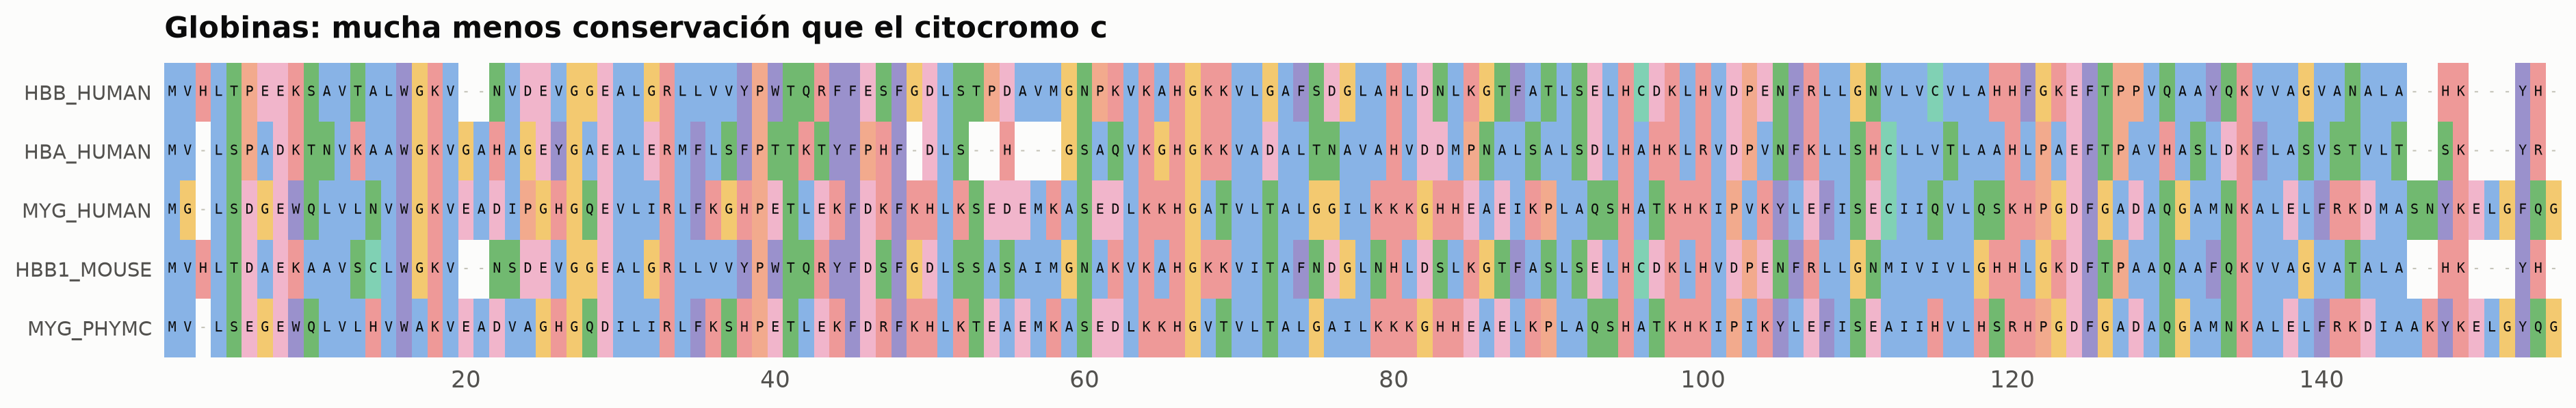

Las mioglobinas y las hemoglobinas α y β divergieron hace más de 500 millones de años y toleran
muchas sustituciones mientras se conserve el plegamiento; el citocromo c interactúa con varios socios
proteicos y casi toda su superficie está restringida.


In [29]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
glob = load_fasta("globins.fasta", ["P68871", "P69905", "P02144", "P02088", "P02185"])
g_names = [r.id.split("|")[2] for r in glob]; g_seqs = [str(r.seq) for r in glob]
Zg, _ = upgma(distance_matrix(g_seqs))
msa_g = progressive_msa(g_seqs, Zg)
st_g = column_stats(msa_g)
print(f"Columnas 100 % idénticas: {(st_g.identidad == 1).sum()} de {len(st_g)}")
fig, ax = plt.subplots(figsize=(17, 2.6))
draw_msa(ax, msa_g, g_names, fs=6.5)
ax.set_title("Globinas: mucha menos conservación que el citocromo c", loc="left")
plt.show()
print("Las mioglobinas y las hemoglobinas α y β divergieron hace más de 500 millones de años y toleran"
      "\nmuchas sustituciones mientras se conserve el plegamiento; el citocromo c interactúa con varios socios"
      "\nproteicos y casi toda su superficie está restringida.")

In [30]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
I_all, _ = pairwise_identity(best_msa)
weights = 1 / (I_all > 0.8).sum(axis=1)
def weighted_entropy(rows, w):
    H = []
    for c in range(len(rows[0])):
        acc = {}
        for r, wi in zip(rows, w):
            if r[c] != "-":
                acc[r[c]] = acc.get(r[c], 0) + wi
        p = np.array(list(acc.values())); p = p / p.sum()
        H.append(float(-(p * np.log2(p)).sum()))
    return np.array(H)
Hw = weighted_entropy(best_msa, weights)
diff = pd.DataFrame({"columna": stats.columna, "H": stats.entropia, "H_ponderada": Hw,
                     "consenso": stats.consenso}).assign(cambio=lambda d: d.H_ponderada - d.H)
print("Pesos:", {n: round(float(w), 2) for n, w in zip(names, weights)})
print(diff.sort_values("cambio", ascending=False).head(8).round(2).to_string(index=False))
print("Suben las columnas donde los 7 vertebrados comparten un residuo y los demás no: al pesar menos a los"
      "\nvertebrados (redundantes), la diversidad de hongos y plantas cuenta más.")

Pesos: {'Humano': 0.14, 'Ratón': 0.14, 'Caballo': 0.14, 'Pollo': 0.14, 'Rana': 0.14, 'Pez cebra': 0.14, 'Atún': 0.14, 'Mosca': 1.0, 'Gusano (C. elegans)': 1.0, 'Levadura': 1.0, 'Neurospora': 1.0, 'Arabidopsis': 0.5, 'Arroz': 0.5, 'Chlamydomonas': 1.0}
 columna    H  H_ponderada consenso  cambio
     111 1.09         1.66        t    0.58
      29 1.09         1.66        v    0.58
      48 1.63         2.13        k    0.50
      44 0.95         1.38        l    0.43
      45 0.73         1.15        f    0.41
      40 0.73         1.15        n    0.41
     107 0.73         1.15        l    0.41
      17 0.73         1.15        k    0.41
Suben las columnas donde los 7 vertebrados comparten un residuo y los demás no: al pesar menos a los
vertebrados (redundantes), la diversidad de hongos y plantas cuenta más.


## 📌 Resumen

* Un **MSA** pone en columnas las posiciones homólogas de muchas secuencias; la **conservación** por columna
  revela los residuos funcionales (en el citocromo *c*: C14, C17, H18 y M80, que sujetan al hemo).
* La programación dinámica exacta en $k$ dimensiones cuesta $O(n^k 2^k)$: factible con 3 secuencias cortas,
  imposible con 14. El MSA óptimo con puntaje SP es NP-difícil.
* El **puntaje suma de pares** suma BLOSUM62 sobre todos los pares de cada columna (hueco–residuo $= g$,
  hueco–hueco $= 0$). Es sensible a la redundancia de las secuencias.
* La estrategia **progresiva** (Feng y Doolittle): distancias por pares → **árbol guía** (UPGMA) → fusiones
  **perfil contra perfil** siguiendo el árbol. "Una vez hueco, siempre hueco": rápida, pero los errores tempranos no
  se corrigen.
* MAFFT, MUSCLE, T-Coffee y CLUSTAL mejoran esa base con huecos afines, pesos, consistencia y refinamiento
  iterativo.
* Los MSA se evalúan con $Q_{\text{SP}}$ (pares recuperados) y **TC** (columnas completas) frente a una referencia
  estructural o simulada; el costo de los huecos tiene un óptimo intermedio.
* Visualizar el MSA (mosaico químico, entropía, consenso, identidad por pares) es parte del análisis, no un adorno.

**Próxima lección (4.2):** motivos y matrices de posición (PWM) — de una columna conservada a un logo de secuencia.

## 📚 Para profundizar

* Feng, D.-F. & Doolittle, R. F. (1987). Progressive sequence alignment as a prerequisite to correct phylogenetic
  trees. *Journal of Molecular Evolution* 25(4): 351–360.
* Carrillo, H. & Lipman, D. (1988). The multiple sequence alignment problem in biology. *SIAM Journal on Applied
  Mathematics* 48(5): 1073–1082.
* Thompson, J. D., Higgins, D. G. & Gibson, T. J. (1994). CLUSTAL W: improving the sensitivity of progressive
  multiple sequence alignment through sequence weighting, position-specific gap penalties and weight matrix choice.
  *Nucleic Acids Research* 22(22): 4673–4680.
* Notredame, C., Higgins, D. G. & Heringa, J. (2000). T-Coffee: a novel method for fast and accurate multiple
  sequence alignment. *Journal of Molecular Biology* 302(1): 205–217.
* Katoh, K., Misawa, K., Kuma, K. & Miyata, T. (2002). MAFFT: a novel method for rapid multiple sequence alignment
  based on fast Fourier transform. *Nucleic Acids Research* 30(14): 3059–3066.
* Edgar, R. C. (2004). MUSCLE: multiple sequence alignment with high accuracy and high throughput. *Nucleic Acids
  Research* 32(5): 1792–1797.
* Durbin, R., Eddy, S. R., Krogh, A. & Mitchison, G. (1998). *Biological Sequence Analysis*. Cambridge University
  Press — capítulo 6 (alineamiento múltiple).

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)